**Climate Change Vulnerability Assessment - CCVA**
**Purpose of the Analysis**
The objective of this section is to:

1. Quantify SUHII intensity across the urban–rural gradient.
2. 
3. 
4. 

# 1. Default graph

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [5]:
# Load data
ccva_default = pd.read_csv(
    "C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_scores_default.csv"
)

# Filter type == domain 
ccva_default_domain = ccva_default[ccva_default["type"] == "domain"]

# Rename "i_weight" to "d_weight" for domain df
ccva_default_domain = ccva_default_domain.rename(columns={"i_weight": "d_weight"})

# Join domain weights back to the main dataframe
ccva_default = pd.merge(
    ccva_default,
    ccva_default_domain[["dom_id", "d_weight"]],
    on="dom_id",
    how="left"
)

# For 'indicator' rows: multiply d_weight, i_weight, and raw_mean / 100
# For 'domain' rows: multiply d_weight and raw_mean / 100

ccva_default["i_weighted"] = np.where(
    ccva_default["type"] == "indicator",
    ccva_default["d_weight"] * ccva_default["i_weight"] / 100,
    ccva_default["d_weight"]
)

# display the resulting dataframe
print(ccva_default.head())

# save the resulting dataframe to a new CSV file
ccva_default.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_scores_default_bis.csv", index=False)

     dimension     id                                    indicator  i_weight  \
0  Sensitivity  a.1.1                           Employment statuts      25.0   
1  Sensitivity  a.1.2        Percentage of catch from fishing sold      25.0   
2  Sensitivity  a.1.3  Percentage of income from the main activity      25.0   
3  Sensitivity  a.1.4                 Time conducting the activity      25.0   
4  Sensitivity  a.2.1                                       Gender      25.0   

        type  dom_id  d_weight  i_weighted  
0  indicator       1      25.0        6.25  
1  indicator       1      25.0        6.25  
2  indicator       1      25.0        6.25  
3  indicator       1      25.0        6.25  
4  indicator       2      25.0        6.25  


## 1.1 Sensitivity

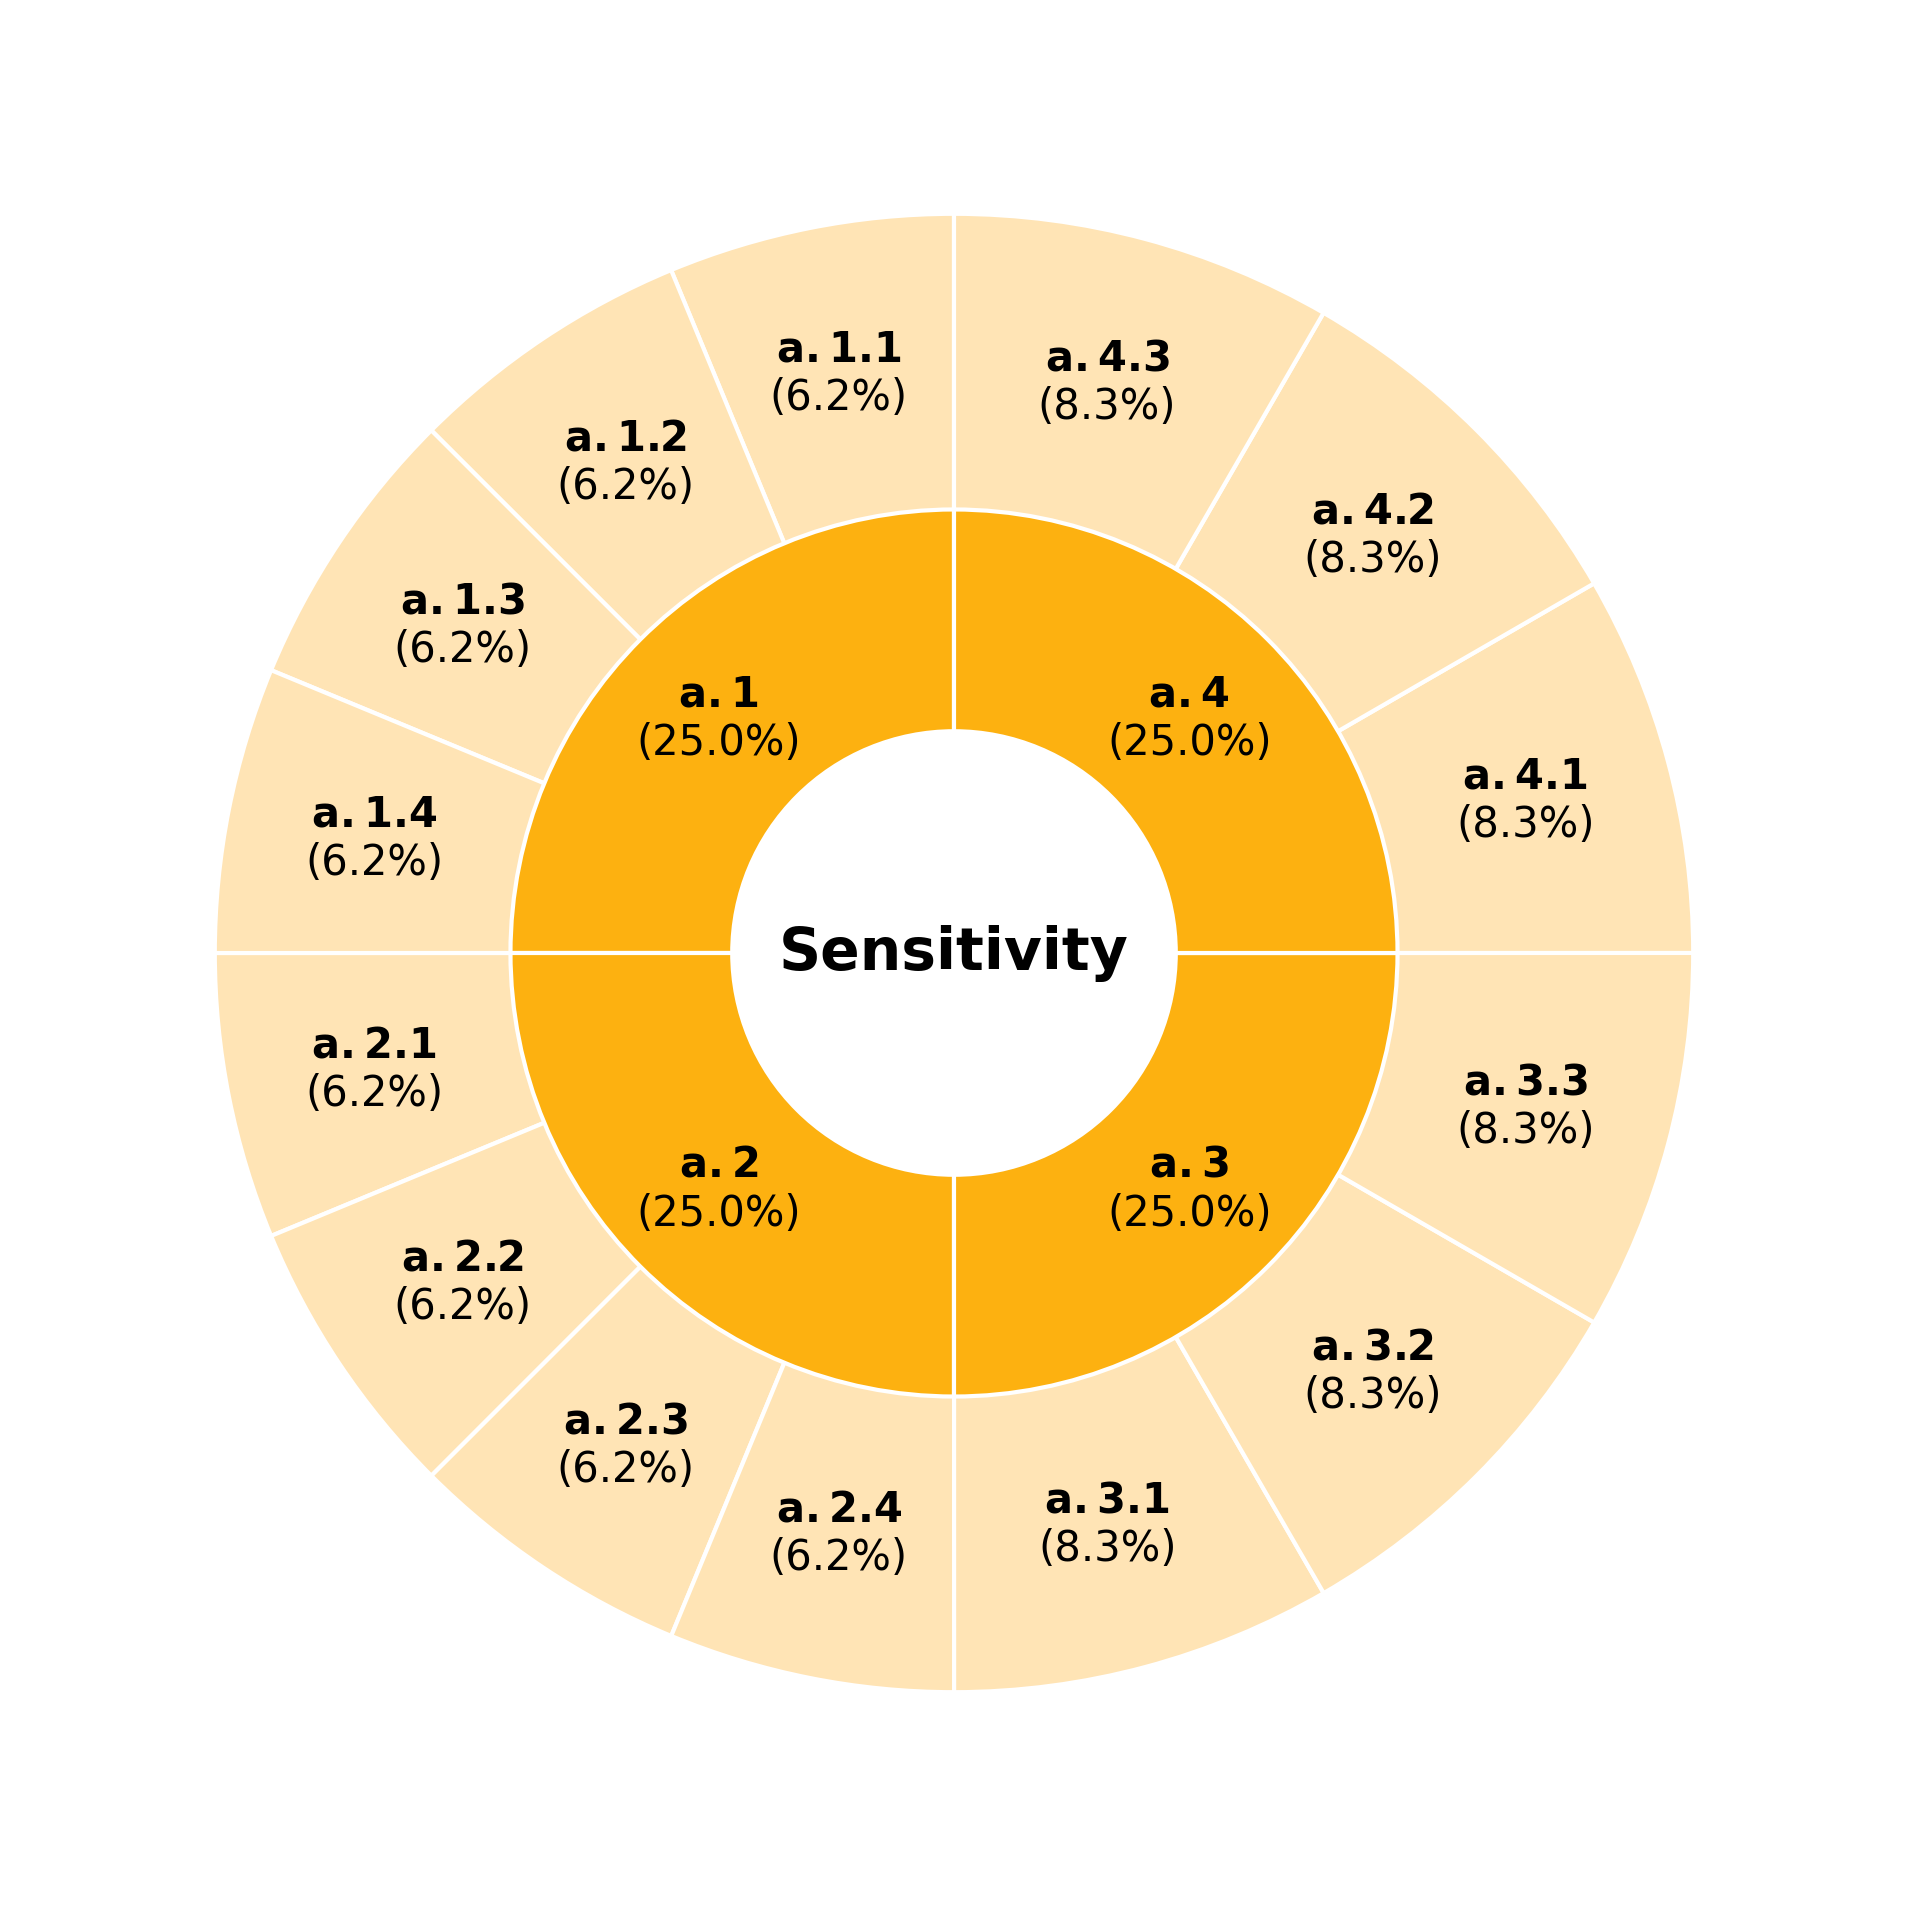

In [6]:
# Filter Sensitivity
df_default = ccva_default[ccva_default["dimension"] == "Sensitivity"]

# Domain weights
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights = df_domain_default.groupby("dom_id")["d_weight"].first()

# Indicator weights
df_indicator_default = df_default[df_default["type"] == "indicator"]
# Sort indicators by dom_id
df_indicator_default = df_indicator_default.sort_values("dom_id")

indicator_weights = df_indicator_default["i_weighted"]

ids = df_indicator_default["id"]
dds = df_domain_default["id"]

# Define custom colors
domain_color = "#FDB110"       # orange
indicator_color = "#FFE4B5"    # light orange

# --- STEP 1: Save chart without labels ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Inner ring (Domains)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Center text
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")

# Save without labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_pie_nolabel.png", bbox_inches='tight')
plt.close()

# --- STEP 2: Add labels and save labeled version ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
wedges_outer, _ = ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Place indicator labels
for wedge, label, value in zip(wedges_outer, ids, indicator_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )

# Inner ring (Domains)
wedges_inner, _ = ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Place domain labels
for wedge, label, value in zip(wedges_inner, dds, domain_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )


# Center text
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")

# Save labeled version
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_pie_label.png", bbox_inches='tight')
plt.show()

## 1.2 Adaptive Capacity

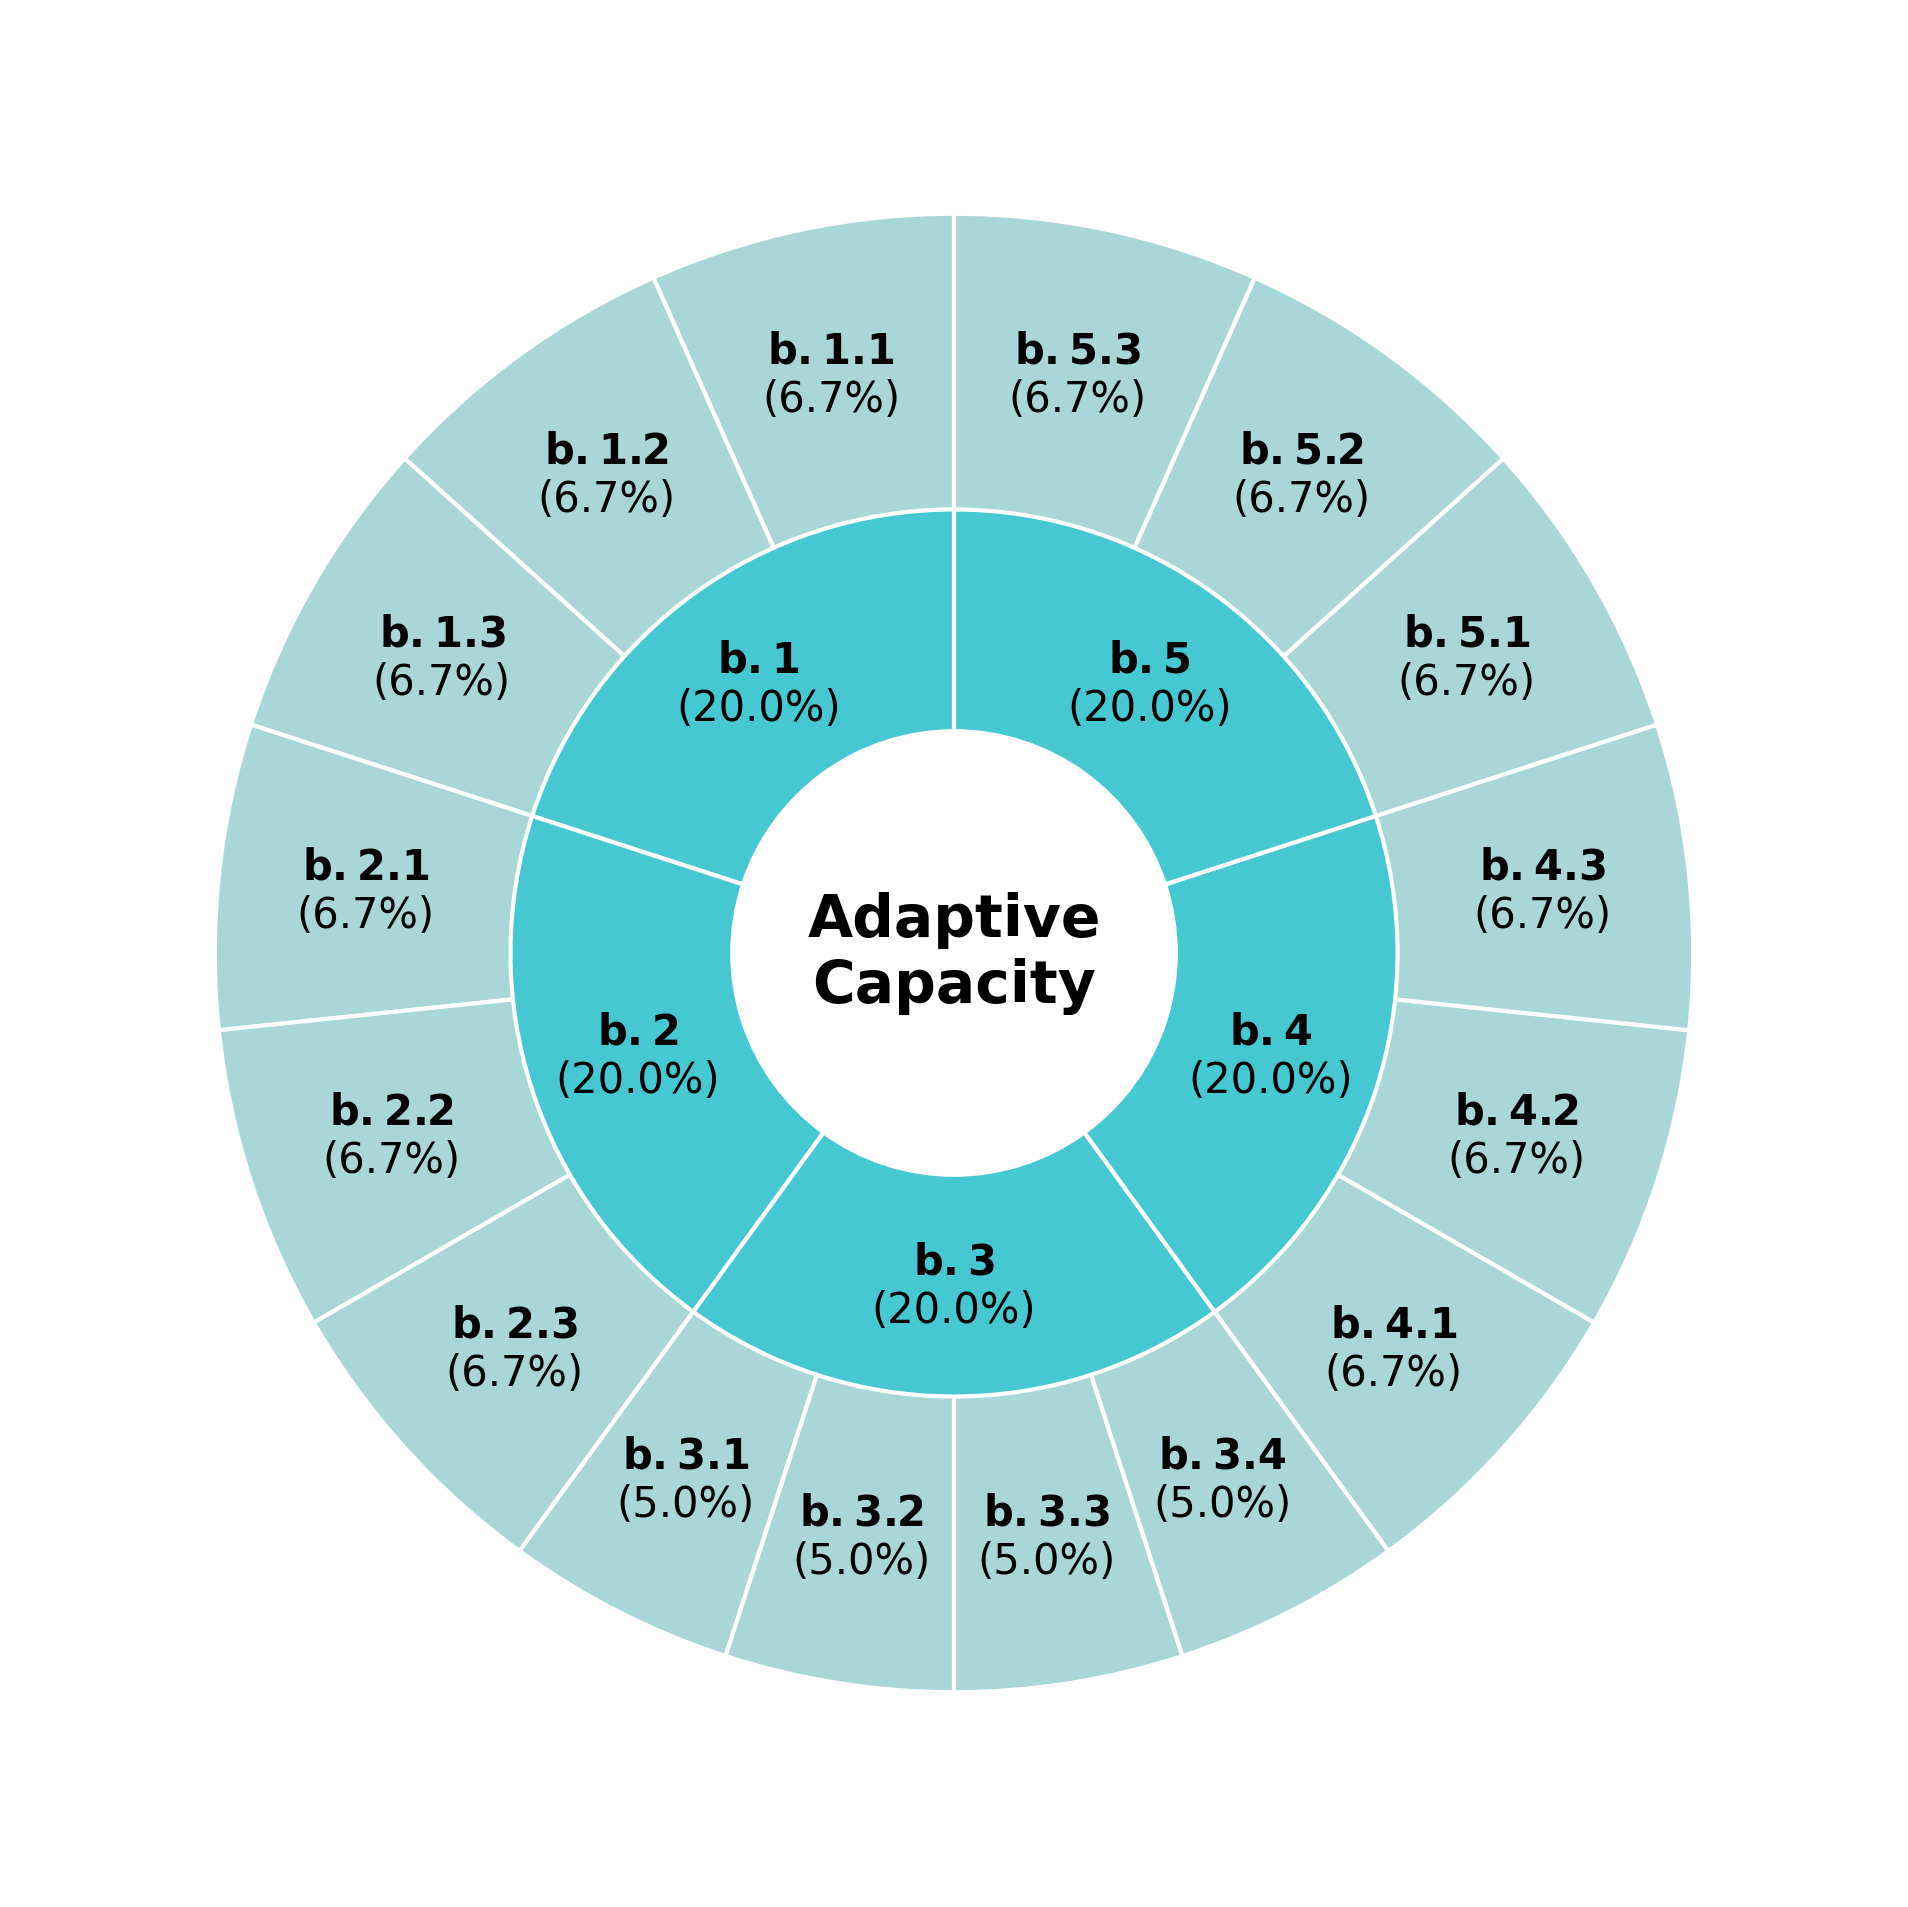

In [7]:
# Filter Adaptive Capacity
df = ccva_default[ccva_default["dimension"] == "Adaptive Capacity"]

# Domain weights
df_domain = df[df["type"] == "domain"]
domain_weights = df_domain.groupby("dom_id")["d_weight"].first()

# Indicator weights
df_indicator = df[df["type"] == "indicator"]
# Sort indicators by dom_id
df_indicator = df_indicator.sort_values("dom_id")

indicator_weights = df_indicator["i_weighted"]

ids = df_indicator["id"]
dds = df_domain["id"]

# Define custom colors
domain_color = "#45C8D2"       # blue
indicator_color = "#A9D7D7"    # light blue

# --- STEP 1: Save chart without labels ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Inner ring (Domains)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Center text
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")

# Save without labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_pie_nolabel.png", bbox_inches='tight')
plt.close()

# --- STEP 2: Add labels and save labeled version ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
wedges_outer, _ = ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Place indicator labels
for wedge, label, value in zip(wedges_outer, ids, indicator_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )

# Inner ring (Domains)
wedges_inner, _ = ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Place domain labels
for wedge, label, value in zip(wedges_inner, dds, domain_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )


# Center text
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")

# Save labeled version
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_pie_label.png", bbox_inches='tight')
plt.show()


# 2. Expert review
## 2.1 Data preparation

In [14]:
# Load data
# Domain
ahp_expert = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_expert.csv")

# Copy the original dataframe
ahp_expert_bis = ahp_expert.copy()

# Filter type == domain 
ahp_expert_domain = ahp_expert_bis[ahp_expert_bis["type"] == "domain"]

# Rename "i_weight" to "d_weight" for domain df
ahp_expert_domain = ahp_expert_domain.rename(columns={"i_weight": "d_weight"})

# Join domain weights back to the main dataframe
ahp_expert_bis = pd.merge(
    ahp_expert_bis,
    ahp_expert_domain[["dom_id", "d_weight"]],
    on="dom_id",
    how="left"
)

# For 'indicator' rows: multiply d_weight, i_weight, and raw_mean / 100
# For 'domain' rows: multiply d_weight and raw_mean / 100

ahp_expert_bis["i_weighted"] = np.where(
    ahp_expert_bis["type"] == "indicator",
    ahp_expert_bis["d_weight"] * ahp_expert_bis["i_weight"] / 100,
    ahp_expert_bis["d_weight"]
)

# display the resulting dataframe
print(ahp_expert_bis.head())

# save the resulting dataframe to a new CSV file
ahp_expert_bis.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_expert_bis.csv", index=False)

     dimension     id id_original  \
0  Sensitivity  a.1.1       a.1.1   
1  Sensitivity  a.1.2       a.1.2   
2  Sensitivity  a.1.3       a.1.3   
3  Sensitivity  a.1.4       a.1.4   
4  Sensitivity  a.2.1       a.2.1   

                                     indicator  i_weight  i_weight_norm  \
0                           Employment statuts      17.4          0.174   
1        Percentage of catch from fishing sold      32.4          0.324   
2  Percentage of income from the main activity      33.8          0.338   
3                 Time conducting the activity      16.4          0.164   
4                                       Gender      25.7          0.257   

        type  dom_id  total_indicator  total_domain  d_weight  i_weighted  
0  indicator       1                4             0      33.0      5.7420  
1  indicator       1                4             0      33.0     10.6920  
2  indicator       1                4             0      33.0     11.1540  
3  indicator       1  

## 2.1 Sensitivity

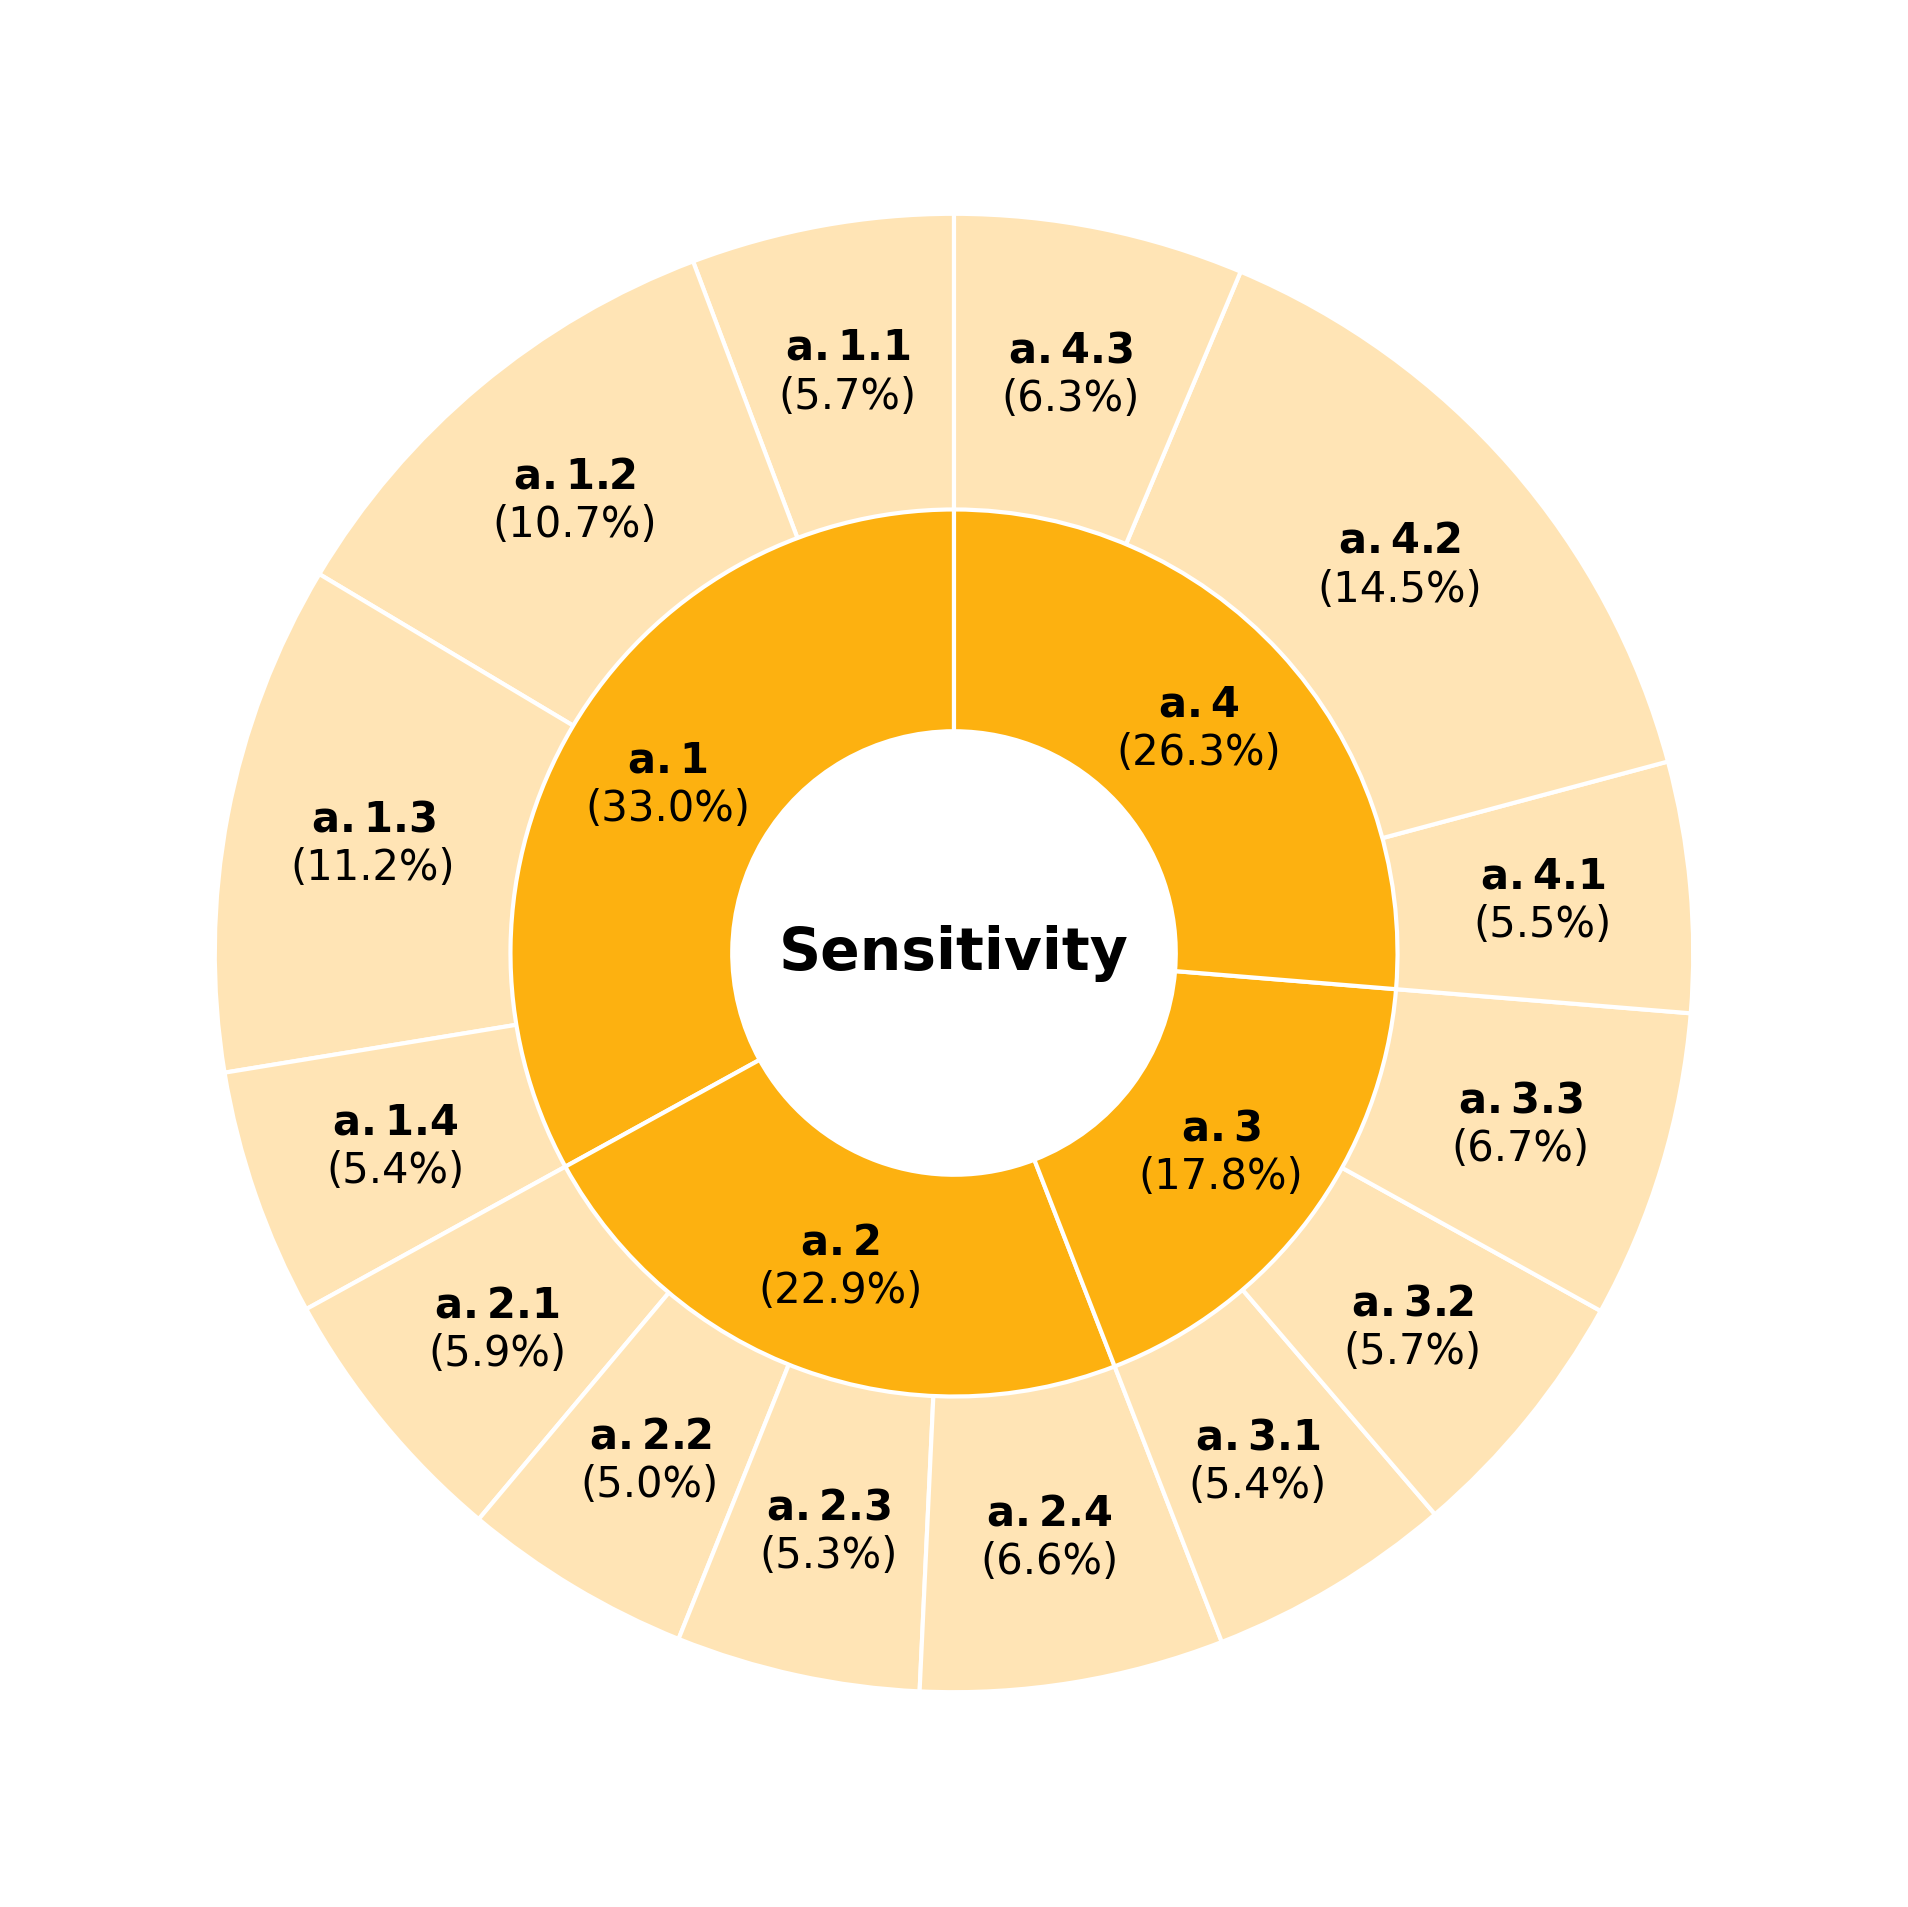

In [31]:
# Filter Sensitivity
df_default = ahp_expert_bis[ahp_expert_bis["dimension"] == "Sensitivity"]

# Domain weights
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights = df_domain_default.groupby("dom_id")["d_weight"].first()

# Indicator weights
df_indicator_default = df_default[df_default["type"] == "indicator"]
# Sort indicators by dom_id
df_indicator_default = df_indicator_default.sort_values("dom_id")

indicator_weights = df_indicator_default["i_weighted"]

ids = df_indicator_default["id"]
dds = df_domain_default["id"]

# Define custom colors
domain_color = "#FDB110"       # orange
indicator_color = "#FFE4B5"    # light orange

# --- STEP 1: Save chart without labels ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Inner ring (Domains)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Center text
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")

# Save without labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_expert_pie_nolabel.png", bbox_inches='tight')
plt.close()

# --- STEP 2: Add labels and save labeled version ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
wedges_outer, _ = ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Place indicator labels
for wedge, label, value in zip(wedges_outer, ids, indicator_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )

# Inner ring (Domains)
wedges_inner, _ = ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Place domain labels
for wedge, label, value in zip(wedges_inner, dds, domain_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )


# Center text
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")

# Save labeled version
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_expert_pie_label.png", bbox_inches='tight')
plt.show()

## 2.2 Adaptive Capacity

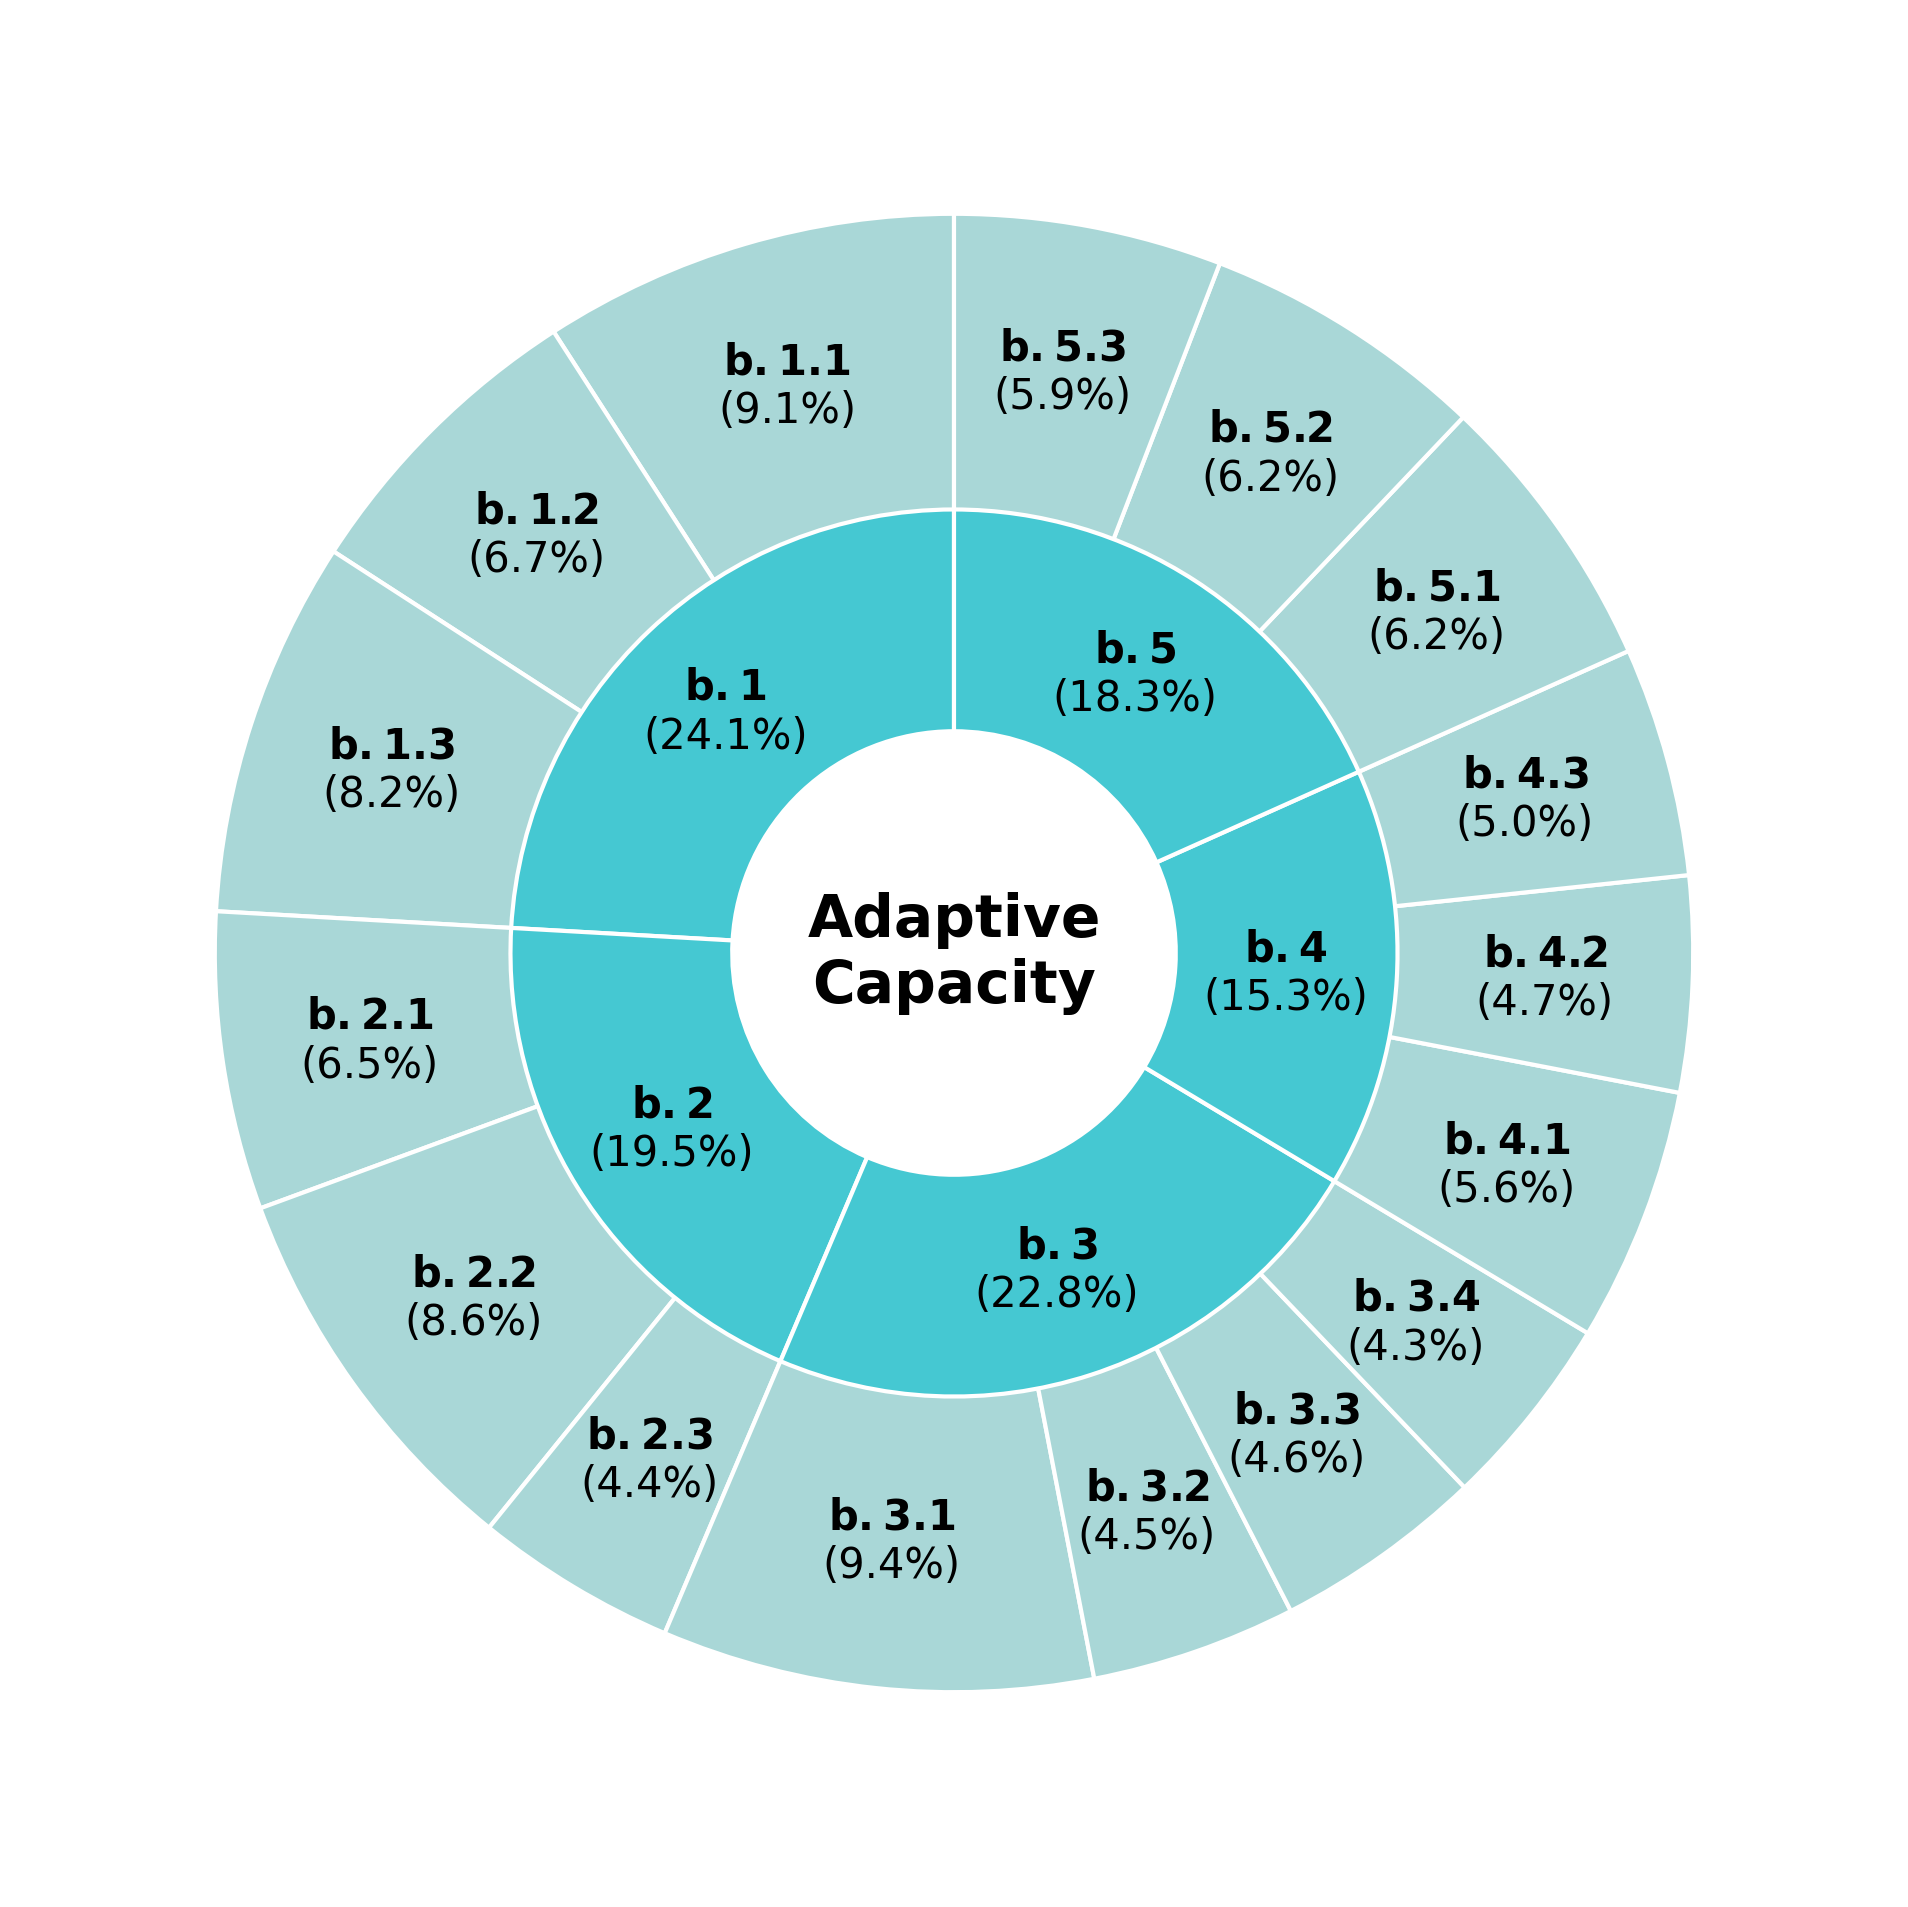

In [32]:
# Filter Adaptive Capacity
df = ahp_expert_bis[ahp_expert_bis["dimension"] == "Adaptive Capacity"]

# Domain weights
df_domain = df[df["type"] == "domain"]
domain_weights = df_domain.groupby("dom_id")["d_weight"].first()

# Indicator weights
df_indicator = df[df["type"] == "indicator"]
# Sort indicators by dom_id
df_indicator = df_indicator.sort_values("dom_id")

indicator_weights = df_indicator["i_weighted"]

ids = df_indicator["id"]
dds = df_domain["id"]

# Define custom colors
domain_color = "#45C8D2"       # blue
indicator_color = "#A9D7D7"    # light blue

# --- STEP 1: Save chart without labels ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Inner ring (Domains)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Center text
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")

# Save without labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_expert_pie_nolabel.png", bbox_inches='tight')
plt.close()

# --- STEP 2: Add labels and save labeled version ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# Outer ring (Indicators)
wedges_outer, _ = ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=[indicator_color]*len(indicator_weights),
    wedgeprops=dict(width=0.6, edgecolor="white")
)

# Place indicator labels
for wedge, label, value in zip(wedges_outer, ids, indicator_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )

# Inner ring (Domains)
wedges_inner, _ = ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=[domain_color]*len(domain_weights),
    wedgeprops=dict(width=0.3, edgecolor="white")
)

# Place domain labels
for wedge, label, value in zip(wedges_inner, dds, domain_weights):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        rf"$\mathbf{{{label}}}$" + f"\n({value*1:.1f}%)",
        ha="center",
        va="center",
        fontsize=10
    )


# Center text
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")

# Save labeled version
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_expert_pie_label.png", bbox_inches='tight')
plt.show()


## 1.3 Consensus

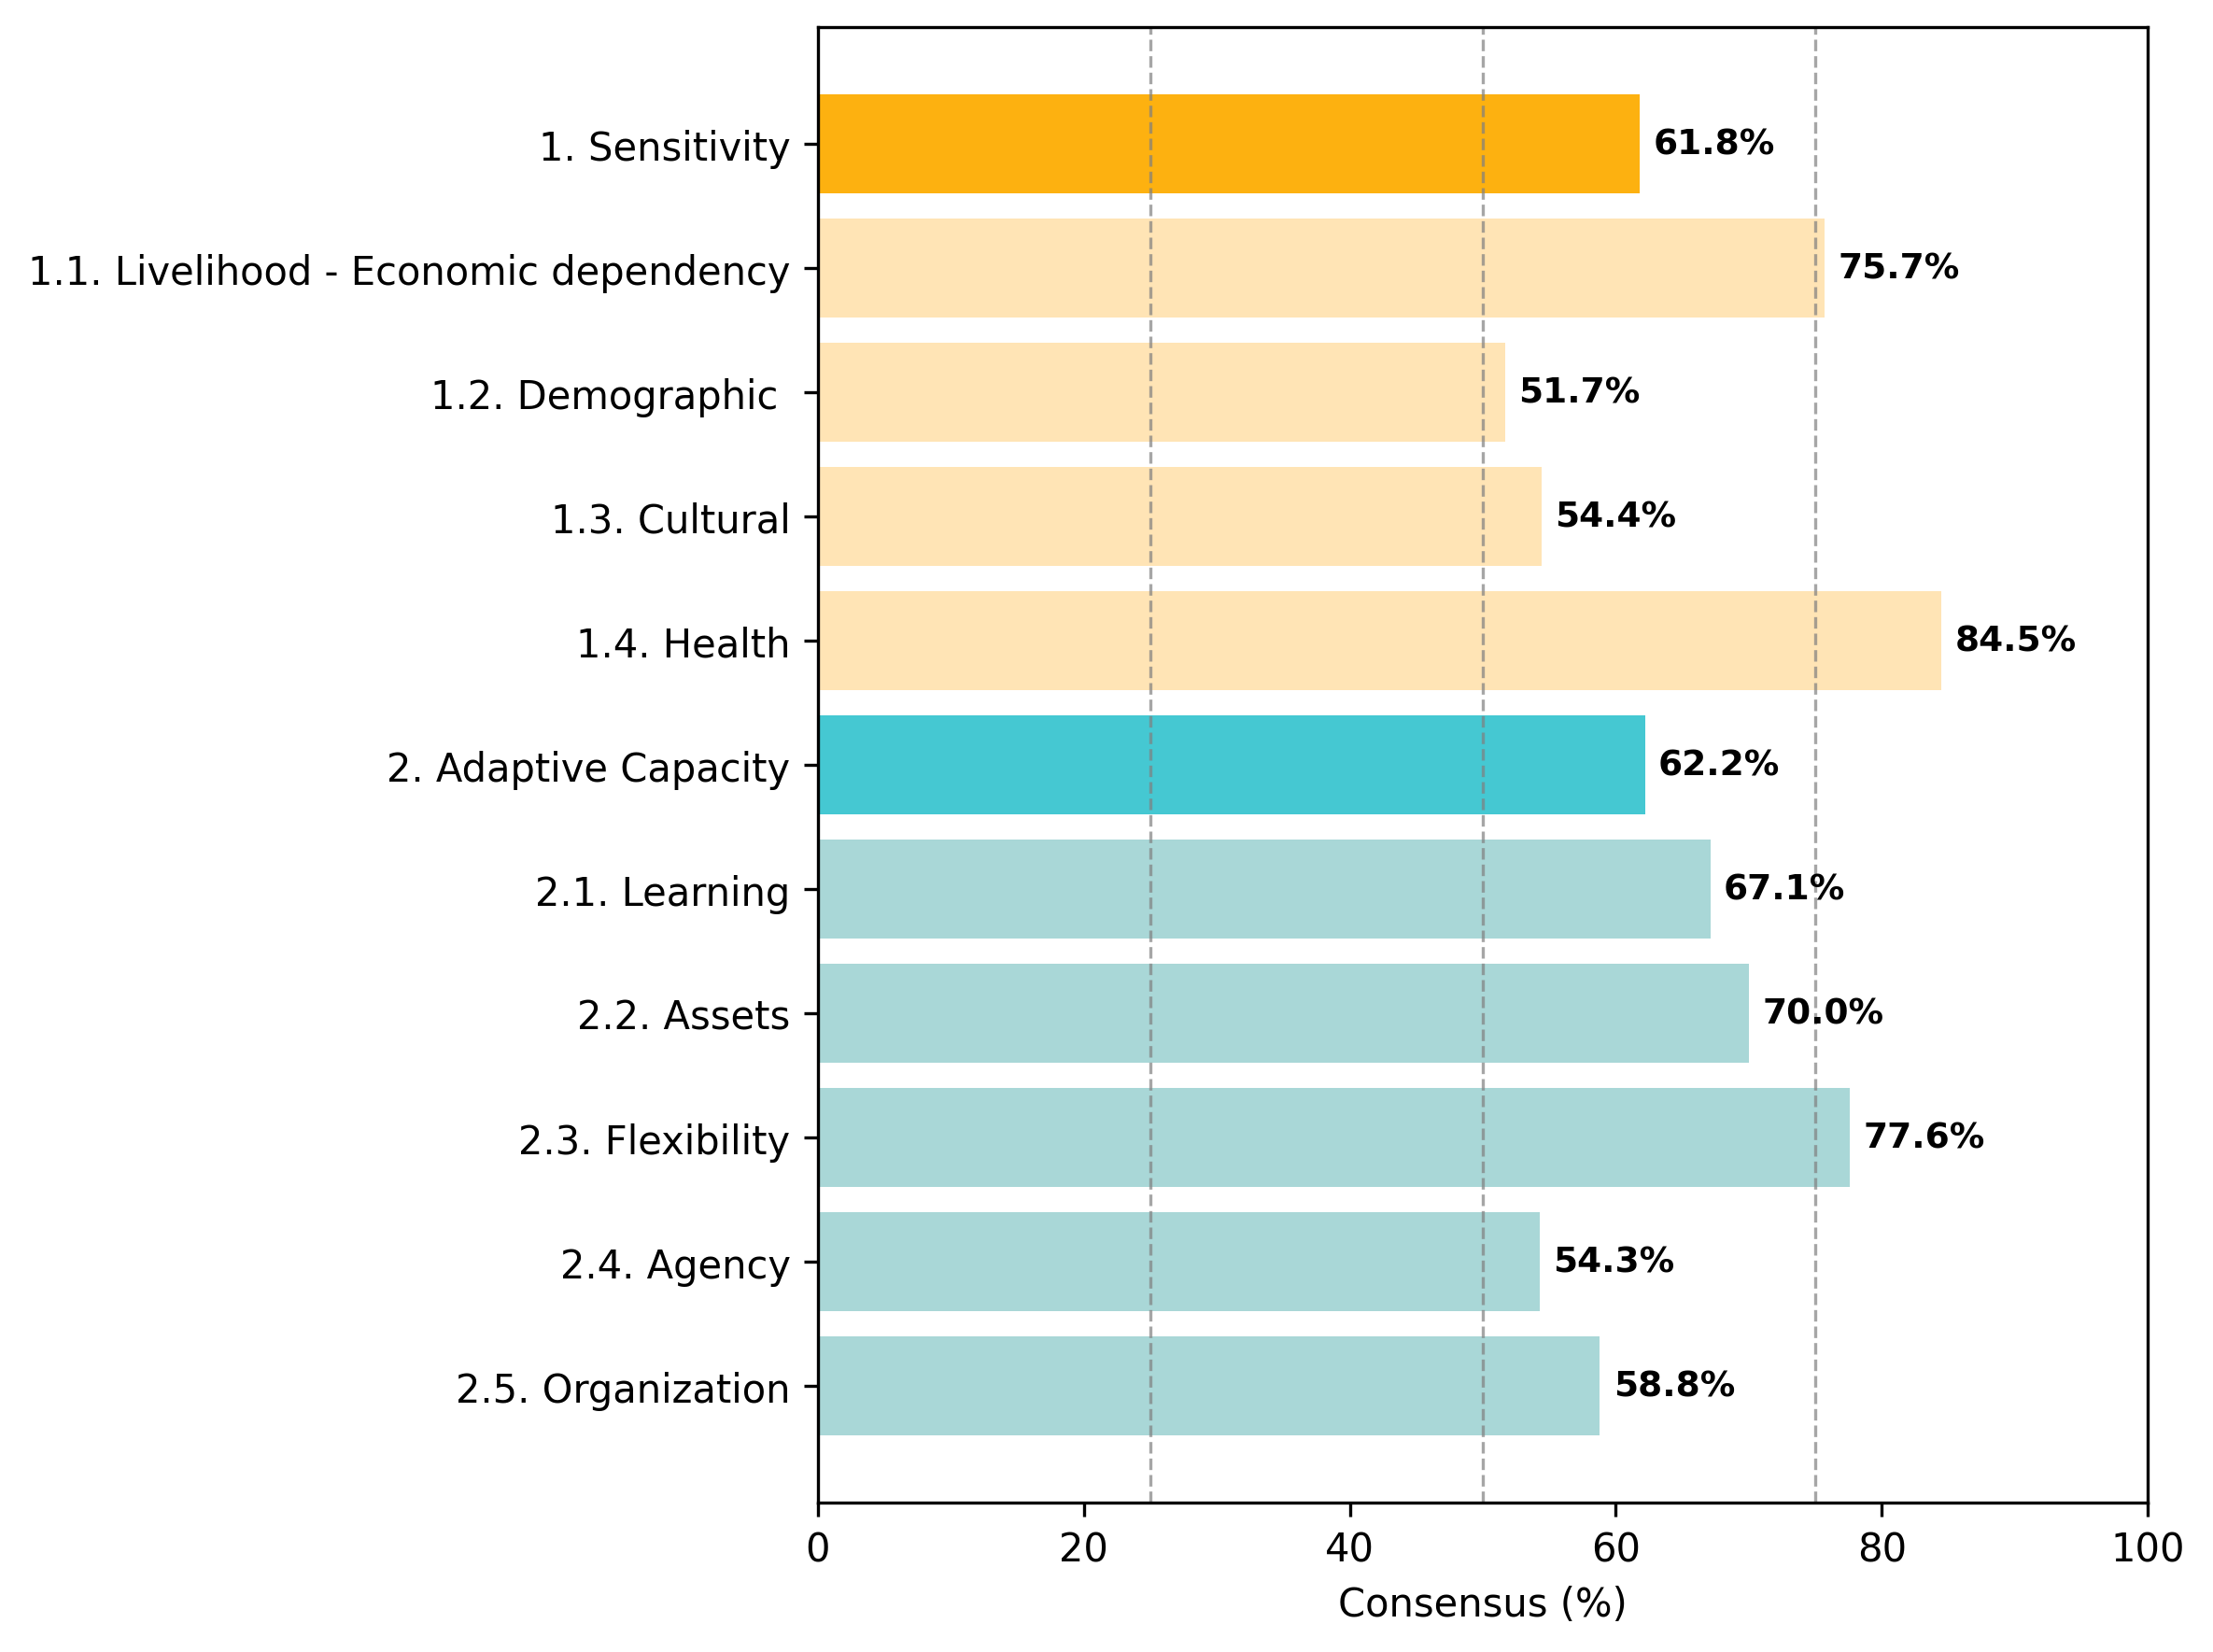

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
consensus_df = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_consensus.csv")

# Map types to colors
color_map = {
    "a": "#FDB110", 
    "aa": "#FFE4B5",   # lighter orange
    "b": "#45C8D2",
    "bb": "#A9D7D7"    # lighter blue
}
bar_colors = consensus_df["type"].map(color_map)

# --- Horizontal bar chart ---
fig, ax = plt.subplots(figsize=(8,6), dpi=300)

# Plot horizontal bars
bars = ax.barh(consensus_df["item"], consensus_df["consensus"], color=bar_colors)

# Reverse y-axis so first item is on top
ax.invert_yaxis()

# Labels and title
ax.set_xlabel("Consensus (%)")
#ax.set_ylabel("Item")
#ax.set_title("Consensus per Item")

# Extend x-axis to 100%
ax.set_xlim(0, 100)

# Add reference lines at 25%, 50%, 75%
for pct in [25, 50, 75]:
    ax.axvline(x=pct, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

# Add labels after the end of each bar
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height()/2
    ax.text(width + 1, y, f"{width:.1f}%", va="center", ha="left", color="black", fontsize=9, weight="bold")

plt.tight_layout()

# Save labeled version
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/consensus_horizontal_bar.png", bbox_inches='tight')
plt.show()


# 3. Household - Default
## 3.1 Data preparation

In [4]:
# Load your dataset
ccva_hh = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh.csv")

# Copy the dataframe to avoid modifying the original
ccva_hh_raw = ccva_hh.copy()

# A domains
ccva_hh_raw["a.1"] = ccva_hh_raw[["a.1.1","a.1.2","a.1.3","a.1.4"]].sum(axis=1)/4
ccva_hh_raw["a.2"] = ccva_hh_raw[["a.2.1","a.2.2","a.2.3","a.2.4"]].sum(axis=1)/4
ccva_hh_raw["a.3"] = ccva_hh_raw[["a.3.1","a.3.2","a.3.3"]].sum(axis=1)/3
ccva_hh_raw["a.4"] = ccva_hh_raw[["a.4.1","a.4.2","a.4.3"]].sum(axis=1)/3

# B domains
ccva_hh_raw["b.1"] = ccva_hh_raw[["b.1.1","b.1.2","b.1.3"]].sum(axis=1)/3
ccva_hh_raw["b.2"] = ccva_hh_raw[["b.2.1","b.2.2","b.2.3"]].sum(axis=1)/3
ccva_hh_raw["b.3"] = ccva_hh_raw[["b.3.1","b.3.2","b.3.3","b.3.4"]].sum(axis=1)/4
ccva_hh_raw["b.4"] = ccva_hh_raw[["b.4.1","b.4.2","b.4.3"]].sum(axis=1)/3
ccva_hh_raw["b.5"] = ccva_hh_raw[["b.5.1","b.5.2","b.5.3"]].sum(axis=1)/3

# Save the updated DataFrame to a new CSV file
ccva_hh_raw.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_raw.csv", index=False)

In [5]:
# Compute mean of each column
# List of columns to average
cols = [
"a.1.1","a.1.2","a.1.3","a.1.4",
"a.2.1","a.2.2","a.2.3","a.2.4",
"a.3.1","a.3.2","a.3.3",
"a.4.1","a.4.2","a.4.3",
"b.1.1","b.1.2","b.1.3",
"b.2.1","b.2.2","b.2.3",
"b.3.1","b.3.2","b.3.3","b.3.4",
"b.4.1","b.4.2","b.4.3",
"b.5.1","b.5.2","b.5.3",
"a.1","a.2","a.3","a.4",
"b.1","b.2","b.3","b.4","b.5"
]

# Compute mean of each column
mean_df_raw = ccva_hh_raw[cols].mean(axis=0).reset_index()

# Rename columns
mean_df_raw.columns = ["id", "raw_mean"]

# Optional: check result
print(mean_df_raw.head())


      id  raw_mean
0  a.1.1  0.940367
1  a.1.2  0.957248
2  a.1.3  0.925361
3  a.1.4  0.226117
4  a.2.1  0.146789


In [6]:
# Load your dataset
metadata = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/dimension_domain_indicator_metadata.csv")

# join with mean_df_raw to get metadata for each indicator/domain
mean_df_raw = pd.merge(
    mean_df_raw, 
    metadata, 
    left_on="id", 
    right_on="id",   # or "indicator_id" if that’s the column name
    how="right"
)

# Optional: check result
print(mean_df_raw.head())

# Save
mean_df_raw.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_raw.csv", index=False)

      id  raw_mean                                         item       type  \
0  a.1.1  0.940367                           Employment statuts  indicator   
1  a.1.2  0.957248        Percentage of catch from fishing sold  indicator   
2  a.1.3  0.925361  Percentage of income from the main activity  indicator   
3  a.1.4  0.226117                 Time conducting the activity  indicator   
4  a.2.1  0.146789                                       Gender  indicator   

   dom_id    dimension  
0       1  Sensitivity  
1       1  Sensitivity  
2       1  Sensitivity  
3       1  Sensitivity  
4       2  Sensitivity  


In [7]:
# Create a new column named score
mean_df_raw["score"] = "baseline"  

# load the default AHP scores
ahp_scores_default = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/ahp_scores_default_bis.csv")

# Keep only 'id' and 'i_weighted', drop the other columns
ahp_scores_default = ahp_scores_default[["id", "i_weight"]]

# Join the AHP scores with the household data to get the weights for each indicator
mean_df_raw = pd.merge(
    mean_df_raw, 
    ahp_scores_default, 
    left_on="id", 
    right_on="id", 
    how="right"
)

mean_df_raw["id_original"] = mean_df_raw["id"]

# Create a new dataframe similar to df_ref
mean_df_raw_marginal= mean_df_raw.copy()

# Invert the 'raw_mean' column
mean_df_raw_marginal["raw_mean"] = 1 - mean_df_raw["raw_mean"]

# Append "_marginal" to the 'item' column
mean_df_raw_marginal["item"] = mean_df_raw_marginal["item"].apply(lambda x: f"{x}_marginal")

# Assign a score to the marginal dataframe
mean_df_raw_marginal["score"] = "marginal"

# Combine score and marginal dataframes
mean_df_raw_full = pd.concat([mean_df_raw, mean_df_raw_marginal], ignore_index=True)

# Optional: check result
print(mean_df_raw_full.head())

# Save combined dataframe
mean_df_raw_full.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_combined_all.csv", index=False)

      id  raw_mean                                         item       type  \
0  a.1.1  0.940367                           Employment statuts  indicator   
1  a.1.2  0.957248        Percentage of catch from fishing sold  indicator   
2  a.1.3  0.925361  Percentage of income from the main activity  indicator   
3  a.1.4  0.226117                 Time conducting the activity  indicator   
4  a.2.1  0.146789                                       Gender  indicator   

   dom_id    dimension     score  i_weight id_original  
0       1  Sensitivity  baseline      25.0       a.1.1  
1       1  Sensitivity  baseline      25.0       a.1.2  
2       1  Sensitivity  baseline      25.0       a.1.3  
3       1  Sensitivity  baseline      25.0       a.1.4  
4       2  Sensitivity  baseline      25.0       a.2.1  


In [8]:
# Filter rows where type == "domain" and score == "baseline"
mean_df_raw_full_domain = mean_df_raw_full[
    (mean_df_raw_full["type"] == "domain") &
    (mean_df_raw_full["score"] == "baseline")
]

# Rename "i_weighted" to "d_weight" for domain dataframe
mean_df_raw_full_domain = mean_df_raw_full_domain.rename(columns={"i_weight": "d_weight"})

# Keep relevant columns for domain dataframes
mean_df_raw_full_domain = mean_df_raw_full_domain[["dom_id", "d_weight"]]

# Merge the domain weights back to the indicator dataframe
mean_df_raw_full= pd.merge(
    mean_df_raw_full,
    mean_df_raw_full_domain,
    on="dom_id",
    how="right"
)

# Save combined dataframe
mean_df_raw_full.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_combined_all.csv", index=False)

In [9]:
# For 'indicator' rows: multiply d_weight, i_weight, and raw_mean / 100
# For 'domain' rows: multiply d_weight and raw_mean / 100

mean_df_raw_full["i_weighted"] = np.where(
    mean_df_raw_full["type"] == "indicator",
    mean_df_raw_full["d_weight"] * mean_df_raw_full["i_weight"] * mean_df_raw_full["raw_mean"] / 100,
    mean_df_raw_full["d_weight"] * mean_df_raw_full["raw_mean"]
)

# add "m" to the id of marginal rows
mean_df_raw_full.loc[mean_df_raw_full["score"] == "marginal", "id"] = mean_df_raw_full.loc[mean_df_raw_full["score"] == "marginal", "id"] + "_m"

# Create a new column named type_score that combines type and score
mean_df_raw_full["type_score"] = mean_df_raw_full["type"] + "_" + mean_df_raw_full["score"]

# Save combined dataframe
mean_df_raw_full.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_combined.csv", index=False)

## 3.2 Plot
### 3.1.1 Sensitivity

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

df = mean_df_raw_full[mean_df_raw_full["dimension"] == "Sensitivity"]

# --- Prepare the "actual" data (underneath) ---
df = df.loc[natsorted(df.index, key=lambda x: df.loc[x, "id"])]
domain_df = df[df["type"] == "domain"]
indicator_df = df[df["type"] == "indicator"]

color_map = {
    "indicator_baseline": "#FFE4B5",
    "indicator_marginal": "#D3D3D3",
    "domain_baseline": "#FDB110",
    "domain_marginal": "#D3D3D3"
}

domain_colors = domain_df["type_score"].map(color_map)
indicator_colors = indicator_df["type_score"].map(color_map)

domain_weights = domain_df["i_weighted"]
indicator_weights = indicator_df["i_weighted"]

# --- Prepare the "default" baseline data (on top) ---
df_default = ccva_default[ccva_default["dimension"] == "Sensitivity"]
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights_default = df_domain_default.groupby("dom_id")["d_weight"].first()

df_indicator_default = df_default[df_default["type"] == "indicator"]
df_indicator_default = df_indicator_default.sort_values("dom_id")
indicator_weights_default = df_indicator_default["i_weighted"]

ids_default = df_indicator_default["id"]
dds_default = df_domain_default["id"]

# --- Default chart style with dashed edges ---
default_fill_color = 'none'   
default_alpha = 0.9               
default_edge_color = "black"      # black outline
default_edge_width = 0.7            # thick outline

# --- Plot ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# --- First, draw the actual df data (underneath) ---
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=indicator_colors,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=1.5)
)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=domain_colors,
    wedgeprops=dict(width=0.3, edgecolor="white", linewidth=1.5)
)

# --- Then, draw the default chart on top (transparent fill, black edges, labeled) ---
wedges_outer_default, _ = ax.pie(
    indicator_weights_default,
    radius=1,
    startangle=90,
    colors=[default_fill_color]*len(indicator_weights_default),
    wedgeprops=dict(width=0.4, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

wedges_inner_default, _ = ax.pie(
    domain_weights_default,
    radius=0.6,
    startangle=90,
    colors=[default_fill_color]*len(domain_weights_default),
    wedgeprops=dict(width=0.3, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

# --- Label default chart wedges ---
label_texts = []

for wedge, label in zip(wedges_outer_default, ids_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

for wedge, label in zip(wedges_inner_default, dds_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

# --- Center text ---
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")
# Equal aspect
ax.set(aspect="equal")

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_raw_hh_label.png", dpi=300, bbox_inches="tight")

# Remove labels
for txt in label_texts:
    txt.remove()

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_raw_hh_no_label.png", dpi=300, bbox_inches="tight")
plt.show()



NameError: name 'mean_df_raw_full' is not defined

### 3.1.2 Adaptive Capacity

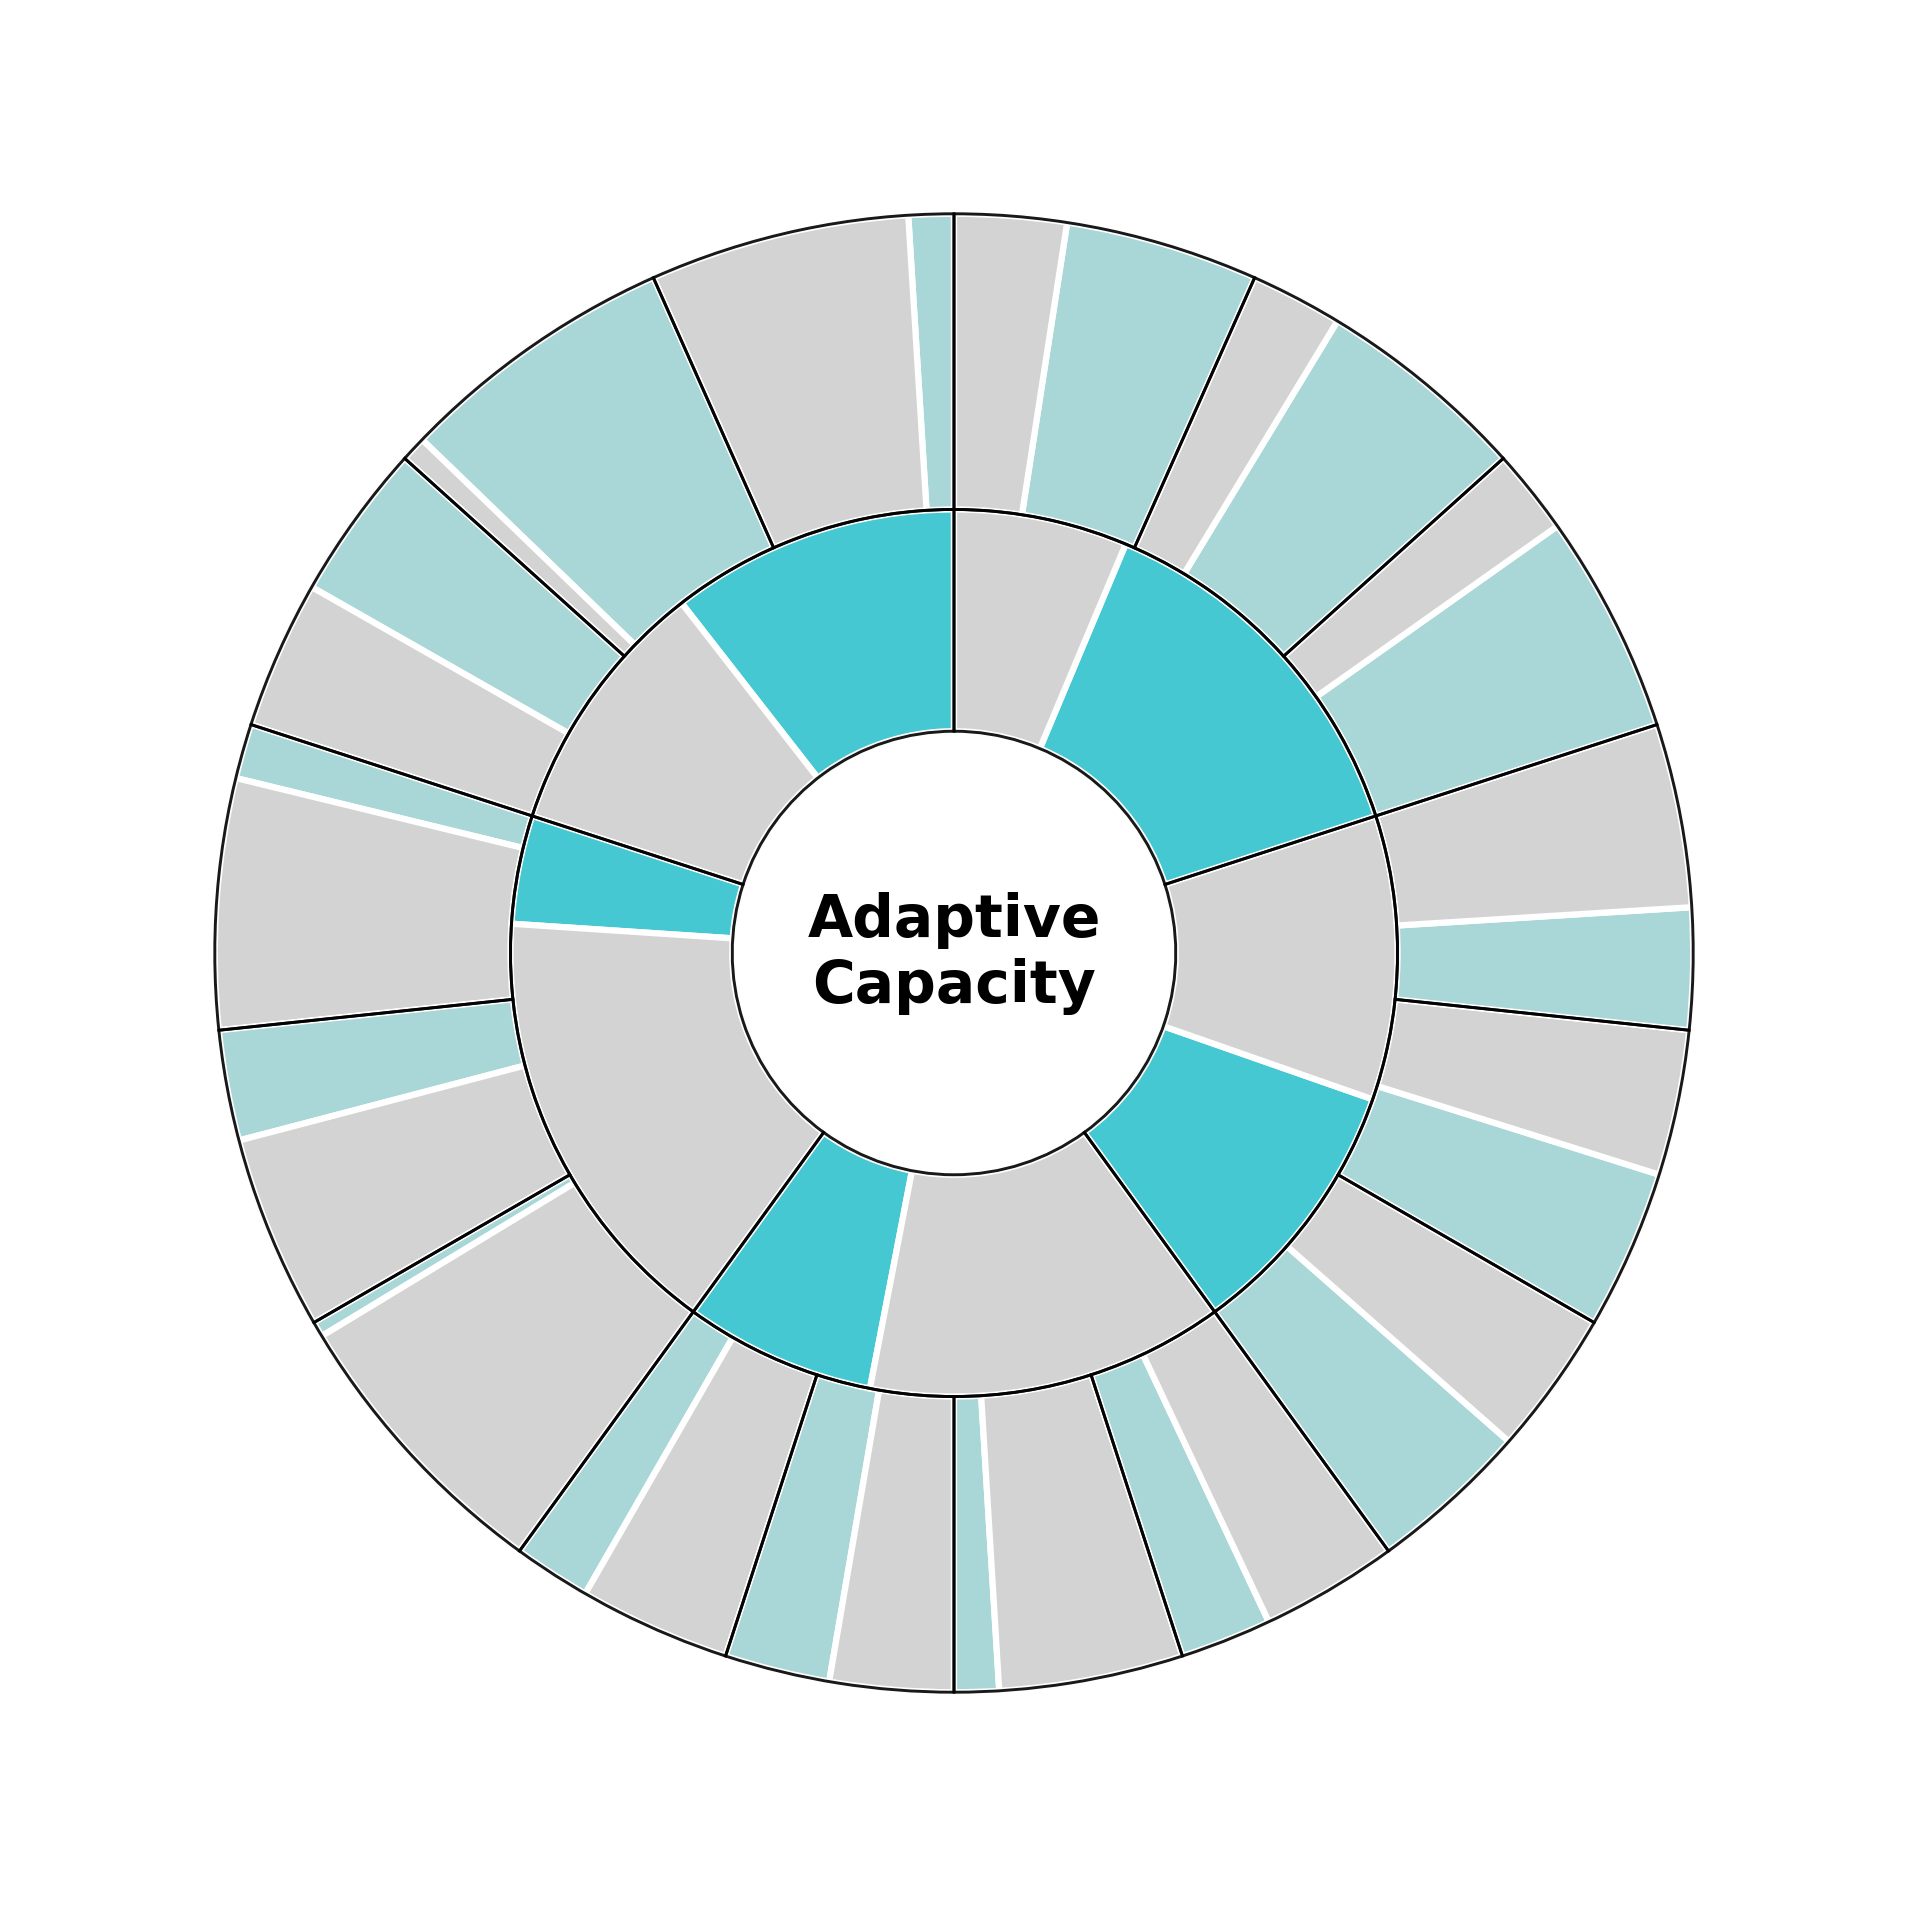

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

# --- Prepare the "actual" data (underneath) ---
df = mean_df_raw_full[mean_df_raw_full["dimension"] == "Adaptive Capacity"]
df = df.loc[natsorted(df.index, key=lambda x: df.loc[x, "id"])]
domain_df = df[df["type"] == "domain"]
indicator_df = df[df["type"] == "indicator"]

color_map = {
    "indicator_baseline": "#A9D7D7",
    "indicator_marginal": "#D3D3D3",
    "domain_baseline": "#45C8D2",
    "domain_marginal": "#D3D3D3"
}

domain_colors = domain_df["type_score"].map(color_map)
indicator_colors = indicator_df["type_score"].map(color_map)

domain_weights = domain_df["i_weighted"]
indicator_weights = indicator_df["i_weighted"]

# --- Prepare the "default" baseline data (on top) ---
df_default = ccva_default[ccva_default["dimension"] == "Adaptive Capacity"]
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights_default = df_domain_default.groupby("dom_id")["d_weight"].first()

df_indicator_default = df_default[df_default["type"] == "indicator"]
df_indicator_default = df_indicator_default.sort_values("dom_id")
indicator_weights_default = df_indicator_default["i_weighted"]

ids_default = df_indicator_default["id"]
dds_default = df_domain_default["id"]

# --- Default chart style with dashed edges ---
default_fill_color = 'none'   # grayish fill
default_alpha = 0.9               # 40% opacity
default_edge_color = "black"      # black outline
default_edge_width = 0.7            # thick outline

# --- Plot ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# --- First, draw the actual df data (underneath) ---
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=indicator_colors,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=1.5)
)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=domain_colors,
    wedgeprops=dict(width=0.3, edgecolor="white", linewidth=1.5)
)

# --- Then, draw the default chart on top (transparent fill, black edges, labeled) ---
wedges_outer_default, _ = ax.pie(
    indicator_weights_default,
    radius=1,
    startangle=90,
    colors=[default_fill_color]*len(indicator_weights_default),
    wedgeprops=dict(width=0.4, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

wedges_inner_default, _ = ax.pie(
    domain_weights_default,
    radius=0.6,
    startangle=90,
    colors=[default_fill_color]*len(domain_weights_default),
    wedgeprops=dict(width=0.3, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

# --- Label default chart wedges ---
label_texts = []

for wedge, label in zip(wedges_outer_default, ids_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

for wedge, label in zip(wedges_inner_default, dds_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

# --- Center text ---
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")
# Equal aspect
ax.set(aspect="equal")

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_raw_hh_label.png", dpi=300, bbox_inches="tight")

# Remove labels
for txt in label_texts:
    txt.remove()

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_raw_hh_no_label.png", dpi=300, bbox_inches="tight")
plt.show()



# 4 Household - Aggregation
## 4.1 Data preparation

In [10]:
# Use this data mean_df_raw 
# Use the ahp_expert as weight
# Copy the dataframe to avoid modifying the original
mean_df_weighted = mean_df_raw.copy()

# For mean_df_raw data drop "i_weight" because we will join a new weight from expert 
mean_df_weighted = mean_df_weighted.drop(columns=["i_weight"])

# Create a new column named score that will be either baseline or marginal to ensure the total of i_weighted is 1
mean_df_weighted ["score"] = "baseline" 

# display first few rows to check
print(mean_df_weighted.head(10))

      id  raw_mean                                          item       type  \
0  a.1.1  0.940367                            Employment statuts  indicator   
1  a.1.2  0.957248         Percentage of catch from fishing sold  indicator   
2  a.1.3  0.925361   Percentage of income from the main activity  indicator   
3  a.1.4  0.226117                  Time conducting the activity  indicator   
4  a.2.1  0.146789                                        Gender  indicator   
5  a.2.2  0.295060                   Years living in the village  indicator   
6  a.2.3  0.418434  Percentage of children in the family members  indicator   
7  a.2.4  0.470278                  Percentage Family dependency  indicator   
8  a.3.1  0.711009                  Appreciation of biodiversity  indicator   
9  a.3.2  0.463303                            Identity and pride  indicator   

   dom_id    dimension     score id_original  
0       1  Sensitivity  baseline       a.1.1  
1       1  Sensitivity  baseline    

In [11]:
# Create a new dataframe similar to mean_df_weighted to add marginal
mean_df_weighted_marginal= mean_df_weighted.copy()

# Assign a score to the marginal dataframe
mean_df_weighted_marginal["score"] = "marginal"

# add "m" to the id of marginal rows
mean_df_weighted_marginal.loc[mean_df_weighted_marginal["score"] == "marginal", "id"] = mean_df_weighted_marginal.loc[mean_df_weighted_marginal["score"] == "marginal", "id"] + "_m"

# Invert the 'raw_mean' column
mean_df_weighted_marginal["raw_mean"] = 1 - mean_df_weighted["raw_mean"]

# display first few rows to check
print(mean_df_weighted_marginal.head(10))

        id  raw_mean                                          item       type  \
0  a.1.1_m  0.059633                            Employment statuts  indicator   
1  a.1.2_m  0.042752         Percentage of catch from fishing sold  indicator   
2  a.1.3_m  0.074639   Percentage of income from the main activity  indicator   
3  a.1.4_m  0.773883                  Time conducting the activity  indicator   
4  a.2.1_m  0.853211                                        Gender  indicator   
5  a.2.2_m  0.704940                   Years living in the village  indicator   
6  a.2.3_m  0.581566  Percentage of children in the family members  indicator   
7  a.2.4_m  0.529722                  Percentage Family dependency  indicator   
8  a.3.1_m  0.288991                  Appreciation of biodiversity  indicator   
9  a.3.2_m  0.536697                            Identity and pride  indicator   

   dom_id    dimension     score id_original  
0       1  Sensitivity  marginal       a.1.1  
1       1  Sen

In [12]:
# Combine Marginal with Baseline
mean_df_weighted_combined= pd.concat([mean_df_weighted_marginal, mean_df_weighted], ignore_index=True)

# Create a new column named type_score that combines type and score
mean_df_weighted_combined["type_score"] = mean_df_weighted_combined["type"] + "_" + mean_df_weighted_combined["score"]

# display first few rows to check
print(mean_df_weighted_combined.head(5))

        id  raw_mean                                         item       type  \
0  a.1.1_m  0.059633                           Employment statuts  indicator   
1  a.1.2_m  0.042752        Percentage of catch from fishing sold  indicator   
2  a.1.3_m  0.074639  Percentage of income from the main activity  indicator   
3  a.1.4_m  0.773883                 Time conducting the activity  indicator   
4  a.2.1_m  0.853211                                       Gender  indicator   

   dom_id    dimension     score id_original          type_score  
0       1  Sensitivity  marginal       a.1.1  indicator_marginal  
1       1  Sensitivity  marginal       a.1.2  indicator_marginal  
2       1  Sensitivity  marginal       a.1.3  indicator_marginal  
3       1  Sensitivity  marginal       a.1.4  indicator_marginal  
4       2  Sensitivity  marginal       a.2.1  indicator_marginal  


In [15]:
# Join with ahp_expert to get the weights for each indicator
mean_df_weighted_combined = pd.merge(
    mean_df_weighted_combined, 
    ahp_expert[["id_original", "i_weight", "total_indicator"]], 
    left_on="id_original", 
    right_on="id_original", 
    how="left"
)

# Filter indicator rows only as domain scores will be recomputed after weighting
mean_df_weighted_indicator = mean_df_weighted_combined[mean_df_weighted_combined["type"] == "indicator"]

# display first few rows to check
print(mean_df_weighted_indicator.head())

        id  raw_mean                                         item       type  \
0  a.1.1_m  0.059633                           Employment statuts  indicator   
1  a.1.2_m  0.042752        Percentage of catch from fishing sold  indicator   
2  a.1.3_m  0.074639  Percentage of income from the main activity  indicator   
3  a.1.4_m  0.773883                 Time conducting the activity  indicator   
4  a.2.1_m  0.853211                                       Gender  indicator   

   dom_id    dimension     score id_original          type_score  i_weight  \
0       1  Sensitivity  marginal       a.1.1  indicator_marginal      17.4   
1       1  Sensitivity  marginal       a.1.2  indicator_marginal      32.4   
2       1  Sensitivity  marginal       a.1.3  indicator_marginal      33.8   
3       1  Sensitivity  marginal       a.1.4  indicator_marginal      16.4   
4       2  Sensitivity  marginal       a.2.1  indicator_marginal      25.7   

   total_indicator  
0                4  
1       

In [16]:
# First aggregation
# Create a new column named "i_weighted" == raw_mean * i_weight (which is the weight of the indicator it belongs to)
mean_df_weighted_indicator["i_weighted"] = mean_df_weighted_indicator["raw_mean"] * mean_df_weighted_indicator["i_weight"] / 100

# display first few rows to check
print(mean_df_weighted_indicator.head())

# Save the new dataframe
mean_df_weighted_indicator.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_weighted_indicator.csv", index=False)

        id  raw_mean                                         item       type  \
0  a.1.1_m  0.059633                           Employment statuts  indicator   
1  a.1.2_m  0.042752        Percentage of catch from fishing sold  indicator   
2  a.1.3_m  0.074639  Percentage of income from the main activity  indicator   
3  a.1.4_m  0.773883                 Time conducting the activity  indicator   
4  a.2.1_m  0.853211                                       Gender  indicator   

   dom_id    dimension     score id_original          type_score  i_weight  \
0       1  Sensitivity  marginal       a.1.1  indicator_marginal      17.4   
1       1  Sensitivity  marginal       a.1.2  indicator_marginal      32.4   
2       1  Sensitivity  marginal       a.1.3  indicator_marginal      33.8   
3       1  Sensitivity  marginal       a.1.4  indicator_marginal      16.4   
4       2  Sensitivity  marginal       a.2.1  indicator_marginal      25.7   

   total_indicator  i_weighted  
0                

c:\Users\percy\Documents\studies\visual_studio_code\ccva\.venv\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [17]:
# Domain
# Filter domain rows only to get the domain weight 
mean_df_weighted_domain_only = mean_df_weighted_combined[
    (mean_df_weighted_combined["type"] == "domain") 
]

# Filter baseline to get one weight per domain
mean_df_weighted_domain_get_weight = mean_df_weighted_domain_only[
        (mean_df_weighted_domain_only["score"] == "baseline")
]

# Rename i_weight to d_weight
mean_df_weighted_domain_get_weight.rename(columns={"i_weight": "d_weight"}, inplace=True)

# display first few rows to check
print(mean_df_weighted_domain_get_weight.head())

     id  raw_mean                              item    type  dom_id  \
69  a.1  0.762273  Livelihood - Economic dependency  domain       1   
70  a.2  0.332640                      Demographic   domain       2   
71  a.3  0.642202                          Cultural  domain       3   
72  a.4  0.408705                            Health  domain       4   
73  b.1  0.526376                          Learning  domain       5   

            dimension     score id_original       type_score  d_weight  \
69        Sensitivity  baseline         a.1  domain_baseline      33.0   
70        Sensitivity  baseline         a.2  domain_baseline      22.9   
71        Sensitivity  baseline         a.3  domain_baseline      17.8   
72        Sensitivity  baseline         a.4  domain_baseline      26.3   
73  Adaptive Capacity  baseline         b.1  domain_baseline      24.1   

    total_indicator  
69                0  
70                0  
71                0  
72                0  
73                

c:\Users\percy\Documents\studies\visual_studio_code\ccva\.venv\lib\site-packages\pandas\core\frame.py:5047: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [18]:
# Second aggregation
# Join Indicator to the domain weight
mean_df_weighted_indicator_second = pd.merge(
    mean_df_weighted_indicator, 
    mean_df_weighted_domain_get_weight[["dom_id", "d_weight"]], 
    left_on="dom_id", 
    right_on="dom_id", 
    how="left"
)

# Create a new column named "d_weighted" == i_weight * d_weight 
mean_df_weighted_indicator_second["d_weighted"] = mean_df_weighted_indicator_second["i_weighted"] * mean_df_weighted_indicator_second["d_weight"]

# display first few rows to check
print(mean_df_weighted_indicator_second.head())

# Save the new dataframe
mean_df_weighted_indicator_second.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean_weighted_indicator_second.csv", index=False)

        id  raw_mean                                         item       type  \
0  a.1.1_m  0.059633                           Employment statuts  indicator   
1  a.1.2_m  0.042752        Percentage of catch from fishing sold  indicator   
2  a.1.3_m  0.074639  Percentage of income from the main activity  indicator   
3  a.1.4_m  0.773883                 Time conducting the activity  indicator   
4  a.2.1_m  0.853211                                       Gender  indicator   

   dom_id    dimension     score id_original          type_score  i_weight  \
0       1  Sensitivity  marginal       a.1.1  indicator_marginal      17.4   
1       1  Sensitivity  marginal       a.1.2  indicator_marginal      32.4   
2       1  Sensitivity  marginal       a.1.3  indicator_marginal      33.8   
3       1  Sensitivity  marginal       a.1.4  indicator_marginal      16.4   
4       2  Sensitivity  marginal       a.2.1  indicator_marginal      25.7   

   total_indicator  i_weighted  d_weight  d_weight

In [19]:
# Check if the total values for domain correspond to AHP expert
# Get the agregated values of domain
mean_df_weighted_indicator_second_pivot = mean_df_weighted_indicator_second.pivot_table(
    index=["dom_id", "score"],
    values="d_weighted",
    aggfunc="sum"
).reset_index()

# display first few rows to check
print(mean_df_weighted_indicator_second_pivot.head(10))



   dom_id     score  d_weighted
0       1  baseline   27.179699
1       1  marginal    5.820301
2       2  baseline    7.706161
3       2  marginal   15.193839
4       3  baseline   11.527950
5       3  marginal    6.272050
6       4  baseline   10.051793
7       4  marginal   16.248207
8       5  baseline   11.773016
9       5  marginal   12.326984


In [20]:
# Join the domain result with domain_only
mean_df_weighted_domain_second = pd.merge(
    mean_df_weighted_domain_only, 
    mean_df_weighted_indicator_second_pivot[["dom_id", "score", "d_weighted"]], 
    left_on=["dom_id", "score"], 
    right_on=["dom_id", "score"],
    how="left"
)

# Combine the indicator and domain
mean_df_weighted_domain_indicator = pd.concat([mean_df_weighted_domain_second, mean_df_weighted_indicator_second], ignore_index=True)

# Save the new dataframe
mean_df_weighted_domain_indicator.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mean_df_weighted_domain_indicator.csv", index=False)

In [21]:
# Plot
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

## 4.2 Plot 
### 4.2.1 Sensitivity

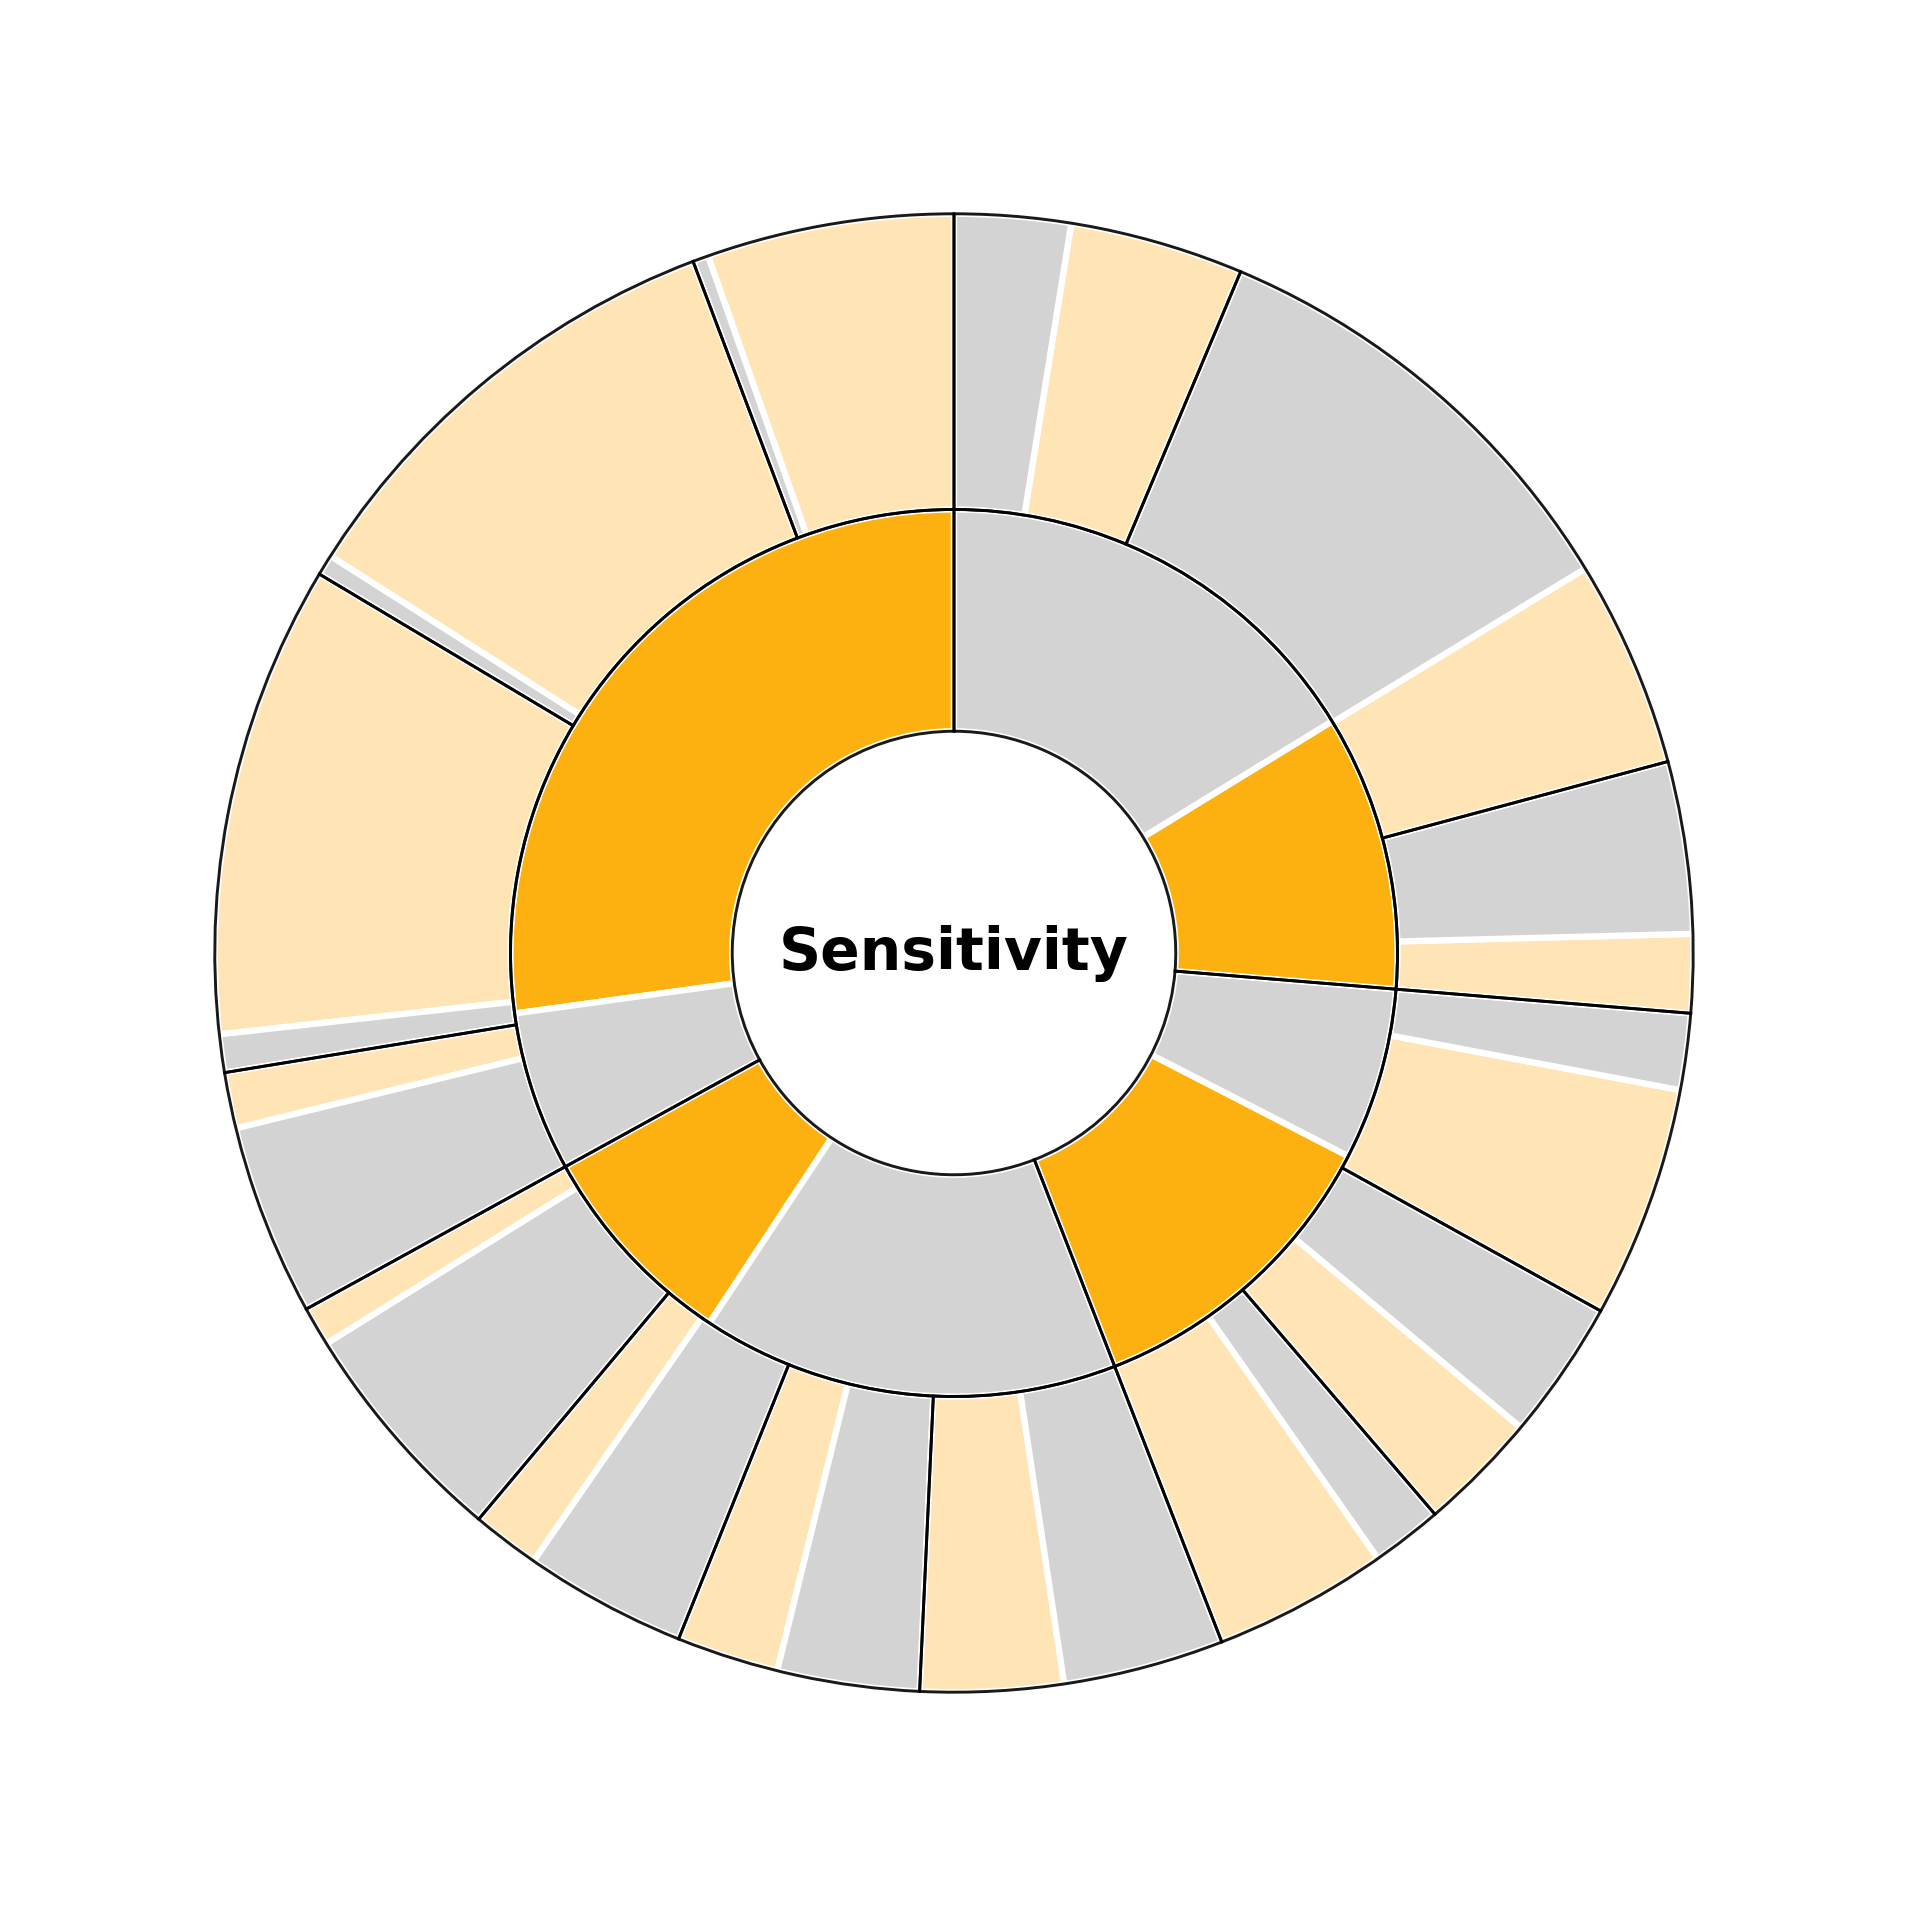

In [22]:

# --- Prepare the "actual" data (underneath) ---
df = mean_df_weighted_domain_indicator[mean_df_weighted_domain_indicator["dimension"] == "Sensitivity"]
df = df.loc[natsorted(df.index, key=lambda x: df.loc[x, "id"])]
domain_df = df[df["type"] == "domain"]
indicator_df = df[df["type"] == "indicator"]

color_map = {
    "indicator_baseline": "#FFE4B5",
    "indicator_marginal": "#D3D3D3",
    "domain_baseline": "#FDB110",
    "domain_marginal": "#D3D3D3"
}

domain_colors = domain_df["type_score"].map(color_map)
indicator_colors = indicator_df["type_score"].map(color_map)

domain_weights = domain_df["d_weighted"]
indicator_weights = indicator_df["d_weighted"]

# --- Prepare the "default" baseline data (on top) ---
df_default = ahp_expert_bis[ahp_expert_bis["dimension"] == "Sensitivity"]
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights_default = df_domain_default.groupby("dom_id")["i_weight"].first()

df_indicator_default = df_default[df_default["type"] == "indicator"]
df_indicator_default = df_indicator_default.sort_values("dom_id")
indicator_weights_default = df_indicator_default["i_weighted"]

ids_default = df_indicator_default["id"]
dds_default = df_domain_default["id"]

# --- Default chart style with dashed edges ---
default_fill_color = 'none'   
default_alpha = 0.9               
default_edge_color = "black"      # black outline
default_edge_width = 0.7            # thick outline

# --- Plot ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# --- First, draw the actual df data (underneath) ---
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=indicator_colors,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=1.5)
)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=domain_colors,
    wedgeprops=dict(width=0.3, edgecolor="white", linewidth=1.5)
)

# --- Then, draw the default chart on top (transparent fill, black edges, labeled) ---
wedges_outer_default, _ = ax.pie(
    indicator_weights_default,
    radius=1,
    startangle=90,
    colors=[default_fill_color]*len(indicator_weights_default),
    wedgeprops=dict(width=0.4, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

wedges_inner_default, _ = ax.pie(
    domain_weights_default,
    radius=0.6,
    startangle=90,
    colors=[default_fill_color]*len(domain_weights_default),
    wedgeprops=dict(width=0.3, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

# --- Label default chart wedges ---
label_texts = []

for wedge, label in zip(wedges_outer_default, ids_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

for wedge, label in zip(wedges_inner_default, dds_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

# --- Center text ---
ax.text(0, 0, "Sensitivity", ha="center", va="center", fontsize=14, weight="bold")
# Equal aspect
ax.set(aspect="equal")

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_weighted_hh_label.png", dpi=300, bbox_inches="tight")

# Remove labels
for txt in label_texts:
    txt.remove()

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/sensitivity_expert_hh_no_label.png", dpi=300, bbox_inches="tight")
plt.show()



### 4.2.2 Adaptive Capacity

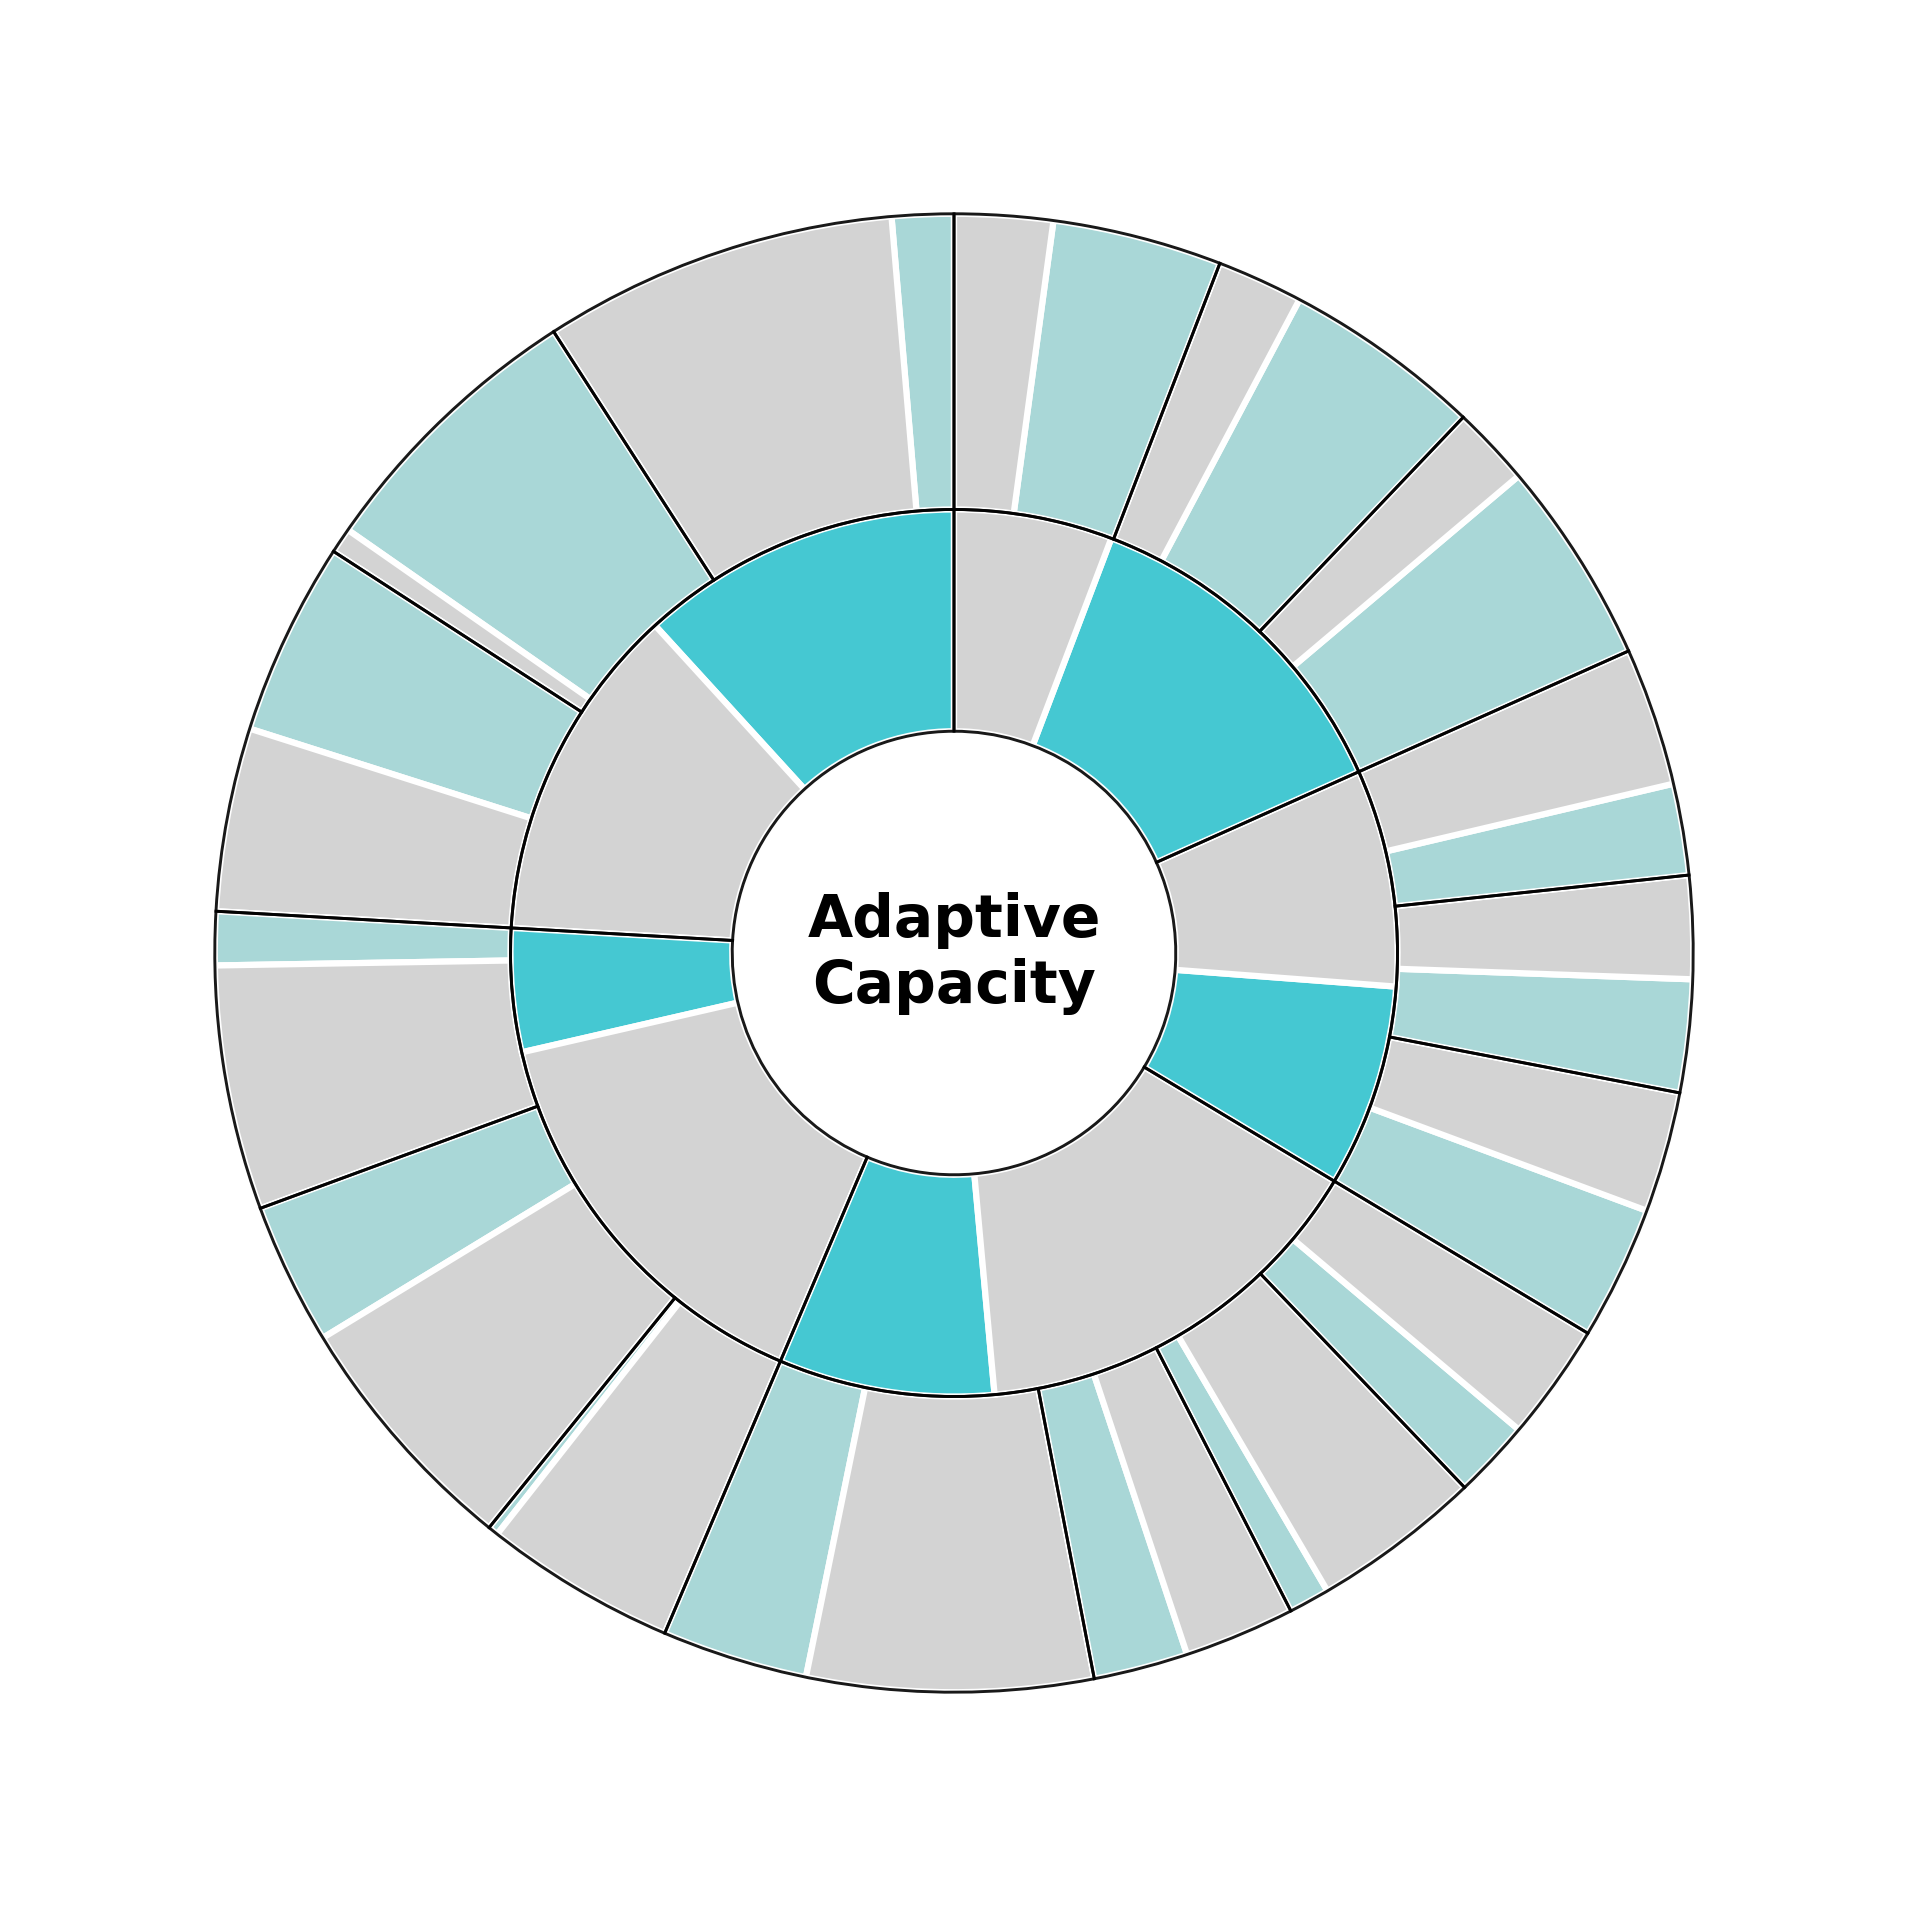

In [ ]:

# --- Prepare the "actual" data (underneath) ---
df = mean_df_weighted_domain_indicator[mean_df_weighted_domain_indicator["dimension"] == "Adaptive Capacity"]
df = df.loc[natsorted(df.index, key=lambda x: df.loc[x, "id"])]
domain_df = df[df["type"] == "domain"]
indicator_df = df[df["type"] == "indicator"]

color_map = {
    "indicator_baseline": "#A9D7D7",
    "indicator_marginal": "#D3D3D3",
    "domain_baseline": "#45C8D2",
    "domain_marginal": "#D3D3D3"
}


domain_colors = domain_df["type_score"].map(color_map)
indicator_colors = indicator_df["type_score"].map(color_map)

domain_weights = domain_df["d_weighted"]
indicator_weights = indicator_df["d_weighted"]

# --- Prepare the "default" baseline data (on top) ---
df_default = ahp_expert_bis[ahp_expert_bis["dimension"] == "Adaptive Capacity"]
df_domain_default = df_default[df_default["type"] == "domain"]
domain_weights_default = df_domain_default.groupby("dom_id")["i_weight"].first()

df_indicator_default = df_default[df_default["type"] == "indicator"]
df_indicator_default = df_indicator_default.sort_values("dom_id")
indicator_weights_default = df_indicator_default["i_weighted"]

ids_default = df_indicator_default["id"]
dds_default = df_domain_default["id"]

# --- Default chart style with dashed edges ---
default_fill_color = 'none'   
default_alpha = 0.9               
default_edge_color = "black"      # black outline
default_edge_width = 0.7            # thick outline

# --- Plot ---
fig, ax = plt.subplots(figsize=(8,8), dpi=300)

# --- First, draw the actual df data (underneath) ---
ax.pie(
    indicator_weights,
    radius=1,
    startangle=90,
    colors=indicator_colors,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=1.5)
)
ax.pie(
    domain_weights,
    radius=0.6,
    startangle=90,
    colors=domain_colors,
    wedgeprops=dict(width=0.3, edgecolor="white", linewidth=1.5)
)

# --- Then, draw the default chart on top (transparent fill, black edges, labeled) ---
wedges_outer_default, _ = ax.pie(
    indicator_weights_default,
    radius=1,
    startangle=90,
    colors=[default_fill_color]*len(indicator_weights_default),
    wedgeprops=dict(width=0.4, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

wedges_inner_default, _ = ax.pie(
    domain_weights_default,
    radius=0.6,
    startangle=90,
    colors=[default_fill_color]*len(domain_weights_default),
    wedgeprops=dict(width=0.3, edgecolor=default_edge_color,
                    linewidth=default_edge_width, alpha=default_alpha)
)

# --- Label default chart wedges ---
label_texts = []

for wedge, label in zip(wedges_outer_default, ids_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.80 * np.cos(np.deg2rad(angle))
    y = 0.80 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

for wedge, label in zip(wedges_inner_default, dds_default):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    txt = ax.text(x, y, rf"$\mathbf{{{label}}}$", ha="center", va="center",
                  fontsize=10, color="black")
    label_texts.append(txt)

# --- Center text ---
ax.text(0, 0, "Adaptive\nCapacity", ha="center", va="center", fontsize=14, weight="bold")
# Equal aspect
ax.set(aspect="equal")

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_weighted_hh_label.png", dpi=300, bbox_inches="tight")

# Remove labels
for txt in label_texts:
    txt.remove()

# Save with labels
plt.savefig("C:/Users/percy/Documents/studies/visual_studio_code/ccva/output/adaptive_capacity_expert_hh_no_label.png", dpi=300, bbox_inches="tight")
plt.show()


# 5 Household comparison between sites: Vulnerability index

In [ ]:
# Indicator weights
# Create dictionary: ind_ID -> i_weight
indicator_weight_dict = dict(zip(ahp_expert_indicator["ind_ID"], ahp_expert_indicator["i_weight_norm"]))

# List of indicators
indicators = [
"a.1.1","a.1.2","a.1.3","a.1.4","a.2.1","a.2.2","a.2.3","a.2.4",
"a.3.1","a.3.2","a.3.3","a.4.1","a.4.2","a.4.3",
"b.1.1","b.1.2","b.1.3","b.2.1","b.2.2","b.2.3",
"b.3.1","b.3.2","b.3.3","b.3.4",
"b.4.1","b.4.2","b.4.3",
"b.5.1","b.5.2","b.5.3"
]

# Add new columns with values from df2
for ind in indicators:
    ccva_hh[ind + "_w"] = indicator_weight_dict.get(ind)

# Create weighted columns
for ind in indicators:
    ccva_hh[ind + "_weighted"] = ccva_hh[ind] * ccva_hh[ind + "_w"]

# Create groups (a.1, a.2, b.3, etc.)
groups = {}
for ind in indicators:
    group = ".".join(ind.split(".")[:2])  # a.1 , b.3 etc
    groups.setdefault(group, []).append(ind + "_weighted")

# Sum columns per group
for g, cols in groups.items():
    ccva_hh[g + "_sum"] = ccva_hh[cols].sum(axis=1)


In [ ]:
# Domain weights
# Create dictionary: dom_ID -> d_weight
domain_weight_dict = dict(zip(ahp_expert_indicator["dom_ID"], ahp_expert_indicator["d_weight_norm"]))

# List of indicators
domains = [
"a.1","a.2","a.3","a.4",
"b.1","b.2","b.3","b.4","b.5"
]

# Add new columns with values from df2
for dom in domains:
    ccva_hh[dom + "_w"] = domain_weight_dict.get(dom)

# Create weighted domain columns
for dom in domains:
    ccva_hh[dom + "_weighted"] = ccva_hh[dom + "_sum"] * ccva_hh[dom + "_w"]


In [48]:
# Dimension sum
# Sum A domains (Sensitivity)
ccva_hh["a_sum"] = ccva_hh[
["a.1_weighted", "a.2_weighted", "a.3_weighted", "a.4_weighted"]
].sum(axis=1)

# Sum B domains (Adaptive Capacity)
ccva_hh["b_sum"] = ccva_hh[
["b.1_weighted", "b.2_weighted", "b.3_weighted", "b.4_weighted", "b.5_weighted"]
].sum(axis=1)

# Save the updated DataFrame to a new CSV file
ccva_hh.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_weighted.csv", index=False)

In [50]:
# List of columns to average
cols = [
"a.1.1_weighted","a.1.2_weighted","a.1.3_weighted","a.1.4_weighted",
"a.2.1_weighted","a.2.2_weighted","a.2.3_weighted","a.2.4_weighted",
"a.3.1_weighted","a.3.2_weighted","a.3.3_weighted",
"a.4.1_weighted","a.4.2_weighted","a.4.3_weighted",
"b.1.1_weighted","b.1.2_weighted","b.1.3_weighted",
"b.2.1_weighted","b.2.2_weighted","b.2.3_weighted",
"b.3.1_weighted","b.3.2_weighted","b.3.3_weighted","b.3.4_weighted",
"b.4.1_weighted","b.4.2_weighted","b.4.3_weighted",
"b.5.1_weighted","b.5.2_weighted","b.5.3_weighted",
"a.1_weighted","a.2_weighted","a.3_weighted","a.4_weighted",
"b.1_weighted","b.2_weighted","b.3_weighted","b.4_weighted","b.5_weighted"
]

# Compute mean of each column
mean_df = ccva_hh[cols].mean(axis=0).reset_index()

# Rename columns
mean_df.columns = ["id", "i_weighted"]

# Remove "_weighted" from item names
mean_df["id"] = mean_df["id"].str.replace("_weighted", "", regex=False)

In [ ]:
# Load the metadata
all_metadata = pd.read_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/dimension_domain_indicator_metadata.csv")

# Merge the mean_df with all_metadata on the 'id' column
mean_df_metadata = pd.merge(mean_df, all_metadata, left_on="id", right_on="id", how="left")


# Save the updated DataFrame to a new CSV file
mean_df_metadata.to_csv("C:/Users/percy/Documents/studies/visual_studio_code/ccva/data/mdg_hh_mean.csv", index=False)

In [30]:
# Filter type = indicator
mean_df_metadata_indicator = mean_df_metadata[mean_df_metadata["type"] == "indicator"]

# Filter type = domain
mean_df_metadata_domain = mean_df_metadata[mean_df_metadata["type"] == "domain"]

# Rename columns "i_weighted" to "d_weighted" for domain df
mean_df_metadata_domain = mean_df_metadata_domain.rename(columns={"i_weight": "d_weight"})


NameError: name 'mean_df_metadata' is not defined

In [ ]:
# Create weighted indicator
ahp_expert_indicator["i_weighted"] = ahp_expert_indicator["d_weight"] * ahp_expert_indicator["i_weight"] / 100